#Import modules

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

#Set results path

In [3]:
results_path = 'drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/CCLE_res'

#Data

In [4]:
rna = pd.read_csv('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/CCLE_transcriptomics_tpm_metabolism_related_genes.csv', index_col = 0 )
rna

,GPT,GUSB,NDUFA7,MAN2B2,CYB5R4,NT5M,CERS2,TENT2,GLYATL2,SLC5A2,...,FABP5,CYP4A22,THEM5,PDE6G,ACER1,ENOPH1,ATP2B4,UGT2B11,NAA60,MTAP
ACH-000358,1.625081,6.696166,7.161072,1.782253,5.110691,3.412770,6.241274,4.595374,1.607993,0.158358,...,9.858383,-0.005746,-0.009275,1.068180,0.000394,6.210562,4.740603,-0.007723,5.556855,5.312199
ACH-000423,0.073437,6.552783,6.348634,0.926233,3.074971,2.313297,6.781158,4.316389,0.683654,0.420848,...,7.747192,0.009853,-0.033136,0.983597,0.000394,5.430171,4.146615,-0.007723,5.003959,4.437186
ACH-000305,0.499719,4.346704,4.842416,2.827733,3.520762,2.488910,7.007866,4.093062,0.019389,0.222997,...,7.072976,0.040593,0.124745,1.270915,0.000394,3.857106,3.499179,-0.007723,4.831581,4.125357
ACH-000115,0.411982,5.889181,6.002387,2.269233,1.945067,2.137013,7.076125,3.648721,1.794568,-0.048879,...,6.958943,0.009853,0.002481,0.067278,0.024525,6.512522,1.802112,0.830438,5.502801,3.839334
ACH-000405,0.742069,5.504427,7.110944,3.054234,4.288493,1.640858,5.579747,5.599207,0.046655,-0.048879,...,8.240958,-0.005746,-0.033136,3.655740,0.000394,5.689351,1.490951,0.006466,4.913972,3.419875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ACH-000811,0.434514,5.157236,6.213981,3.464166,4.427626,1.306580,8.081318,4.883930,0.125358,0.167814,...,7.642639,-0.005746,-0.033136,0.257307,0.000394,5.492344,5.183442,0.806472,5.269029,4.139043
ACH-000772,1.507352,6.120417,6.577882,2.782841,2.370805,2.090823,6.818736,4.955908,4.048804,0.195731,...,9.484702,-0.005746,-0.033136,-0.006798,0.082842,5.755398,4.129259,-0.007723,5.291604,3.879158
ACH-000430,0.122459,6.299095,5.123218,3.072351,2.596416,1.437062,7.264023,4.525830,0.019389,0.465484,...,8.355572,0.009853,-0.033136,0.218541,0.000394,5.292577,6.694022,-0.007723,4.052474,5.055180
ACH-000957,1.479221,5.741245,7.315123,3.562145,3.056095,0.939990,6.675417,4.234586,0.019389,0.805090,...,8.838993,-0.005746,0.092611,0.205396,0.000394,5.790387,3.374747,0.034427,4.785368,4.691053


In [5]:
metabolites = pd.read_csv('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/CCLE_metabolites.csv', index_col = 0)
metabolites

,2-aminoadipate,3-phosphoglycerate,alpha-glycerophosphate,4-pyridoxate,aconitate,adenine,adipate,alpha-ketoglutarate,AMP,citrate,...,C56:8 TAG,C56:7 TAG,C56:6 TAG,C56:5 TAG,C56:4 TAG,C56:3 TAG,C56:2 TAG,C58:8 TAG,C58:7 TAG,C58:6 TAG
ACH-000698,6.112727,6.034198,5.896896,6.000532,5.513618,5.868529,5.977177,5.693074,5.923737,5.641242,...,6.070239,6.133433,6.091089,6.257711,6.372732,6.202511,5.939576,6.309821,6.115974,5.999436
ACH-000489,5.577413,5.727045,5.111468,6.073250,5.802494,5.824473,5.888821,5.768379,5.760784,5.914742,...,6.248653,6.633575,6.378052,6.341043,6.360945,6.333540,6.137271,7.065858,6.832174,6.363064
ACH-000431,5.886398,5.574881,5.541259,5.848375,5.665026,5.875548,5.894904,5.839640,5.742613,5.570208,...,5.942887,5.946988,5.837980,5.913350,6.137530,5.807546,5.704149,5.881193,5.785208,5.504225
ACH-000707,5.770030,6.099229,6.233259,5.543495,5.767759,6.155905,6.111148,5.949481,6.342703,6.054781,...,6.516922,6.113791,6.282113,6.248667,6.109480,6.043570,5.846802,6.429402,5.779815,6.241530
ACH-000509,5.480683,5.469742,6.509397,6.251005,5.190578,5.897085,6.148333,5.607481,5.871600,5.128463,...,6.161981,6.777932,6.676390,6.695659,6.751029,6.385056,6.682612,6.757899,6.728570,6.879260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ACH-000655,5.977636,6.026483,6.480536,6.112056,5.878324,5.732508,5.981183,6.459139,5.642855,6.039198,...,5.547818,5.703861,5.581725,5.506887,5.362247,5.322091,5.556126,5.544802,4.897559,5.506999
ACH-000273,5.957233,6.090834,5.323475,6.145795,5.741201,5.605435,6.184192,6.004195,5.663866,5.758910,...,5.713210,5.651439,5.720680,5.387960,5.275798,5.289684,5.494241,5.533795,5.139488,5.452544
ACH-000504,5.967707,5.931487,5.620542,5.955261,5.935244,5.384674,5.955886,6.239657,5.527619,5.973401,...,5.605403,5.317500,5.630315,5.433324,5.330957,5.481404,5.570553,5.146598,5.010639,5.114385
ACH-000825,5.962415,5.992640,6.296222,5.916386,6.043984,5.883976,5.954731,6.181054,5.820966,6.045409,...,5.949798,6.249271,6.248746,6.130000,5.873297,5.826041,5.997694,6.411166,6.105394,6.387275


In [6]:
threshold = 0.2
nan_percentage = metabolites.isnull().mean()
filtered_metabolites = metabolites.loc[:, nan_percentage <= threshold]
metabolites = filtered_metabolites
metabolites

,2-aminoadipate,3-phosphoglycerate,alpha-glycerophosphate,4-pyridoxate,aconitate,adenine,adipate,alpha-ketoglutarate,AMP,citrate,...,C56:8 TAG,C56:7 TAG,C56:6 TAG,C56:5 TAG,C56:4 TAG,C56:3 TAG,C56:2 TAG,C58:8 TAG,C58:7 TAG,C58:6 TAG
ACH-000698,6.112727,6.034198,5.896896,6.000532,5.513618,5.868529,5.977177,5.693074,5.923737,5.641242,...,6.070239,6.133433,6.091089,6.257711,6.372732,6.202511,5.939576,6.309821,6.115974,5.999436
ACH-000489,5.577413,5.727045,5.111468,6.073250,5.802494,5.824473,5.888821,5.768379,5.760784,5.914742,...,6.248653,6.633575,6.378052,6.341043,6.360945,6.333540,6.137271,7.065858,6.832174,6.363064
ACH-000431,5.886398,5.574881,5.541259,5.848375,5.665026,5.875548,5.894904,5.839640,5.742613,5.570208,...,5.942887,5.946988,5.837980,5.913350,6.137530,5.807546,5.704149,5.881193,5.785208,5.504225
ACH-000707,5.770030,6.099229,6.233259,5.543495,5.767759,6.155905,6.111148,5.949481,6.342703,6.054781,...,6.516922,6.113791,6.282113,6.248667,6.109480,6.043570,5.846802,6.429402,5.779815,6.241530
ACH-000509,5.480683,5.469742,6.509397,6.251005,5.190578,5.897085,6.148333,5.607481,5.871600,5.128463,...,6.161981,6.777932,6.676390,6.695659,6.751029,6.385056,6.682612,6.757899,6.728570,6.879260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ACH-000655,5.977636,6.026483,6.480536,6.112056,5.878324,5.732508,5.981183,6.459139,5.642855,6.039198,...,5.547818,5.703861,5.581725,5.506887,5.362247,5.322091,5.556126,5.544802,4.897559,5.506999
ACH-000273,5.957233,6.090834,5.323475,6.145795,5.741201,5.605435,6.184192,6.004195,5.663866,5.758910,...,5.713210,5.651439,5.720680,5.387960,5.275798,5.289684,5.494241,5.533795,5.139488,5.452544
ACH-000504,5.967707,5.931487,5.620542,5.955261,5.935244,5.384674,5.955886,6.239657,5.527619,5.973401,...,5.605403,5.317500,5.630315,5.433324,5.330957,5.481404,5.570553,5.146598,5.010639,5.114385
ACH-000825,5.962415,5.992640,6.296222,5.916386,6.043984,5.883976,5.954731,6.181054,5.820966,6.045409,...,5.949798,6.249271,6.248746,6.130000,5.873297,5.826041,5.997694,6.411166,6.105394,6.387275


#Remove outliers

In [7]:
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer

def remove_outliers_isolationforest(data, contamination=0.05):
    """Removes outliers using Isolation Forest."""

    # Handle missing values before applying Isolation Forest
    imputer = SimpleImputer(strategy='mean')  # You can use 'median' or another strategy
    data_clean = imputer.fit_transform(data)

    iso = IsolationForest(contamination=contamination)
    yhat = iso.fit_predict(data_clean)
    filtered_data = data[yhat != -1]  # -1 indicates outliers
    return filtered_data

# Apply to your data
filtered_rna = remove_outliers_isolationforest(rna)
filtered_metabolites = remove_outliers_isolationforest(metabolites)

In [8]:
rna = filtered_rna
metabolites = filtered_metabolites

In [9]:
rna

,GPT,GUSB,NDUFA7,MAN2B2,CYB5R4,NT5M,CERS2,TENT2,GLYATL2,SLC5A2,...,FABP5,CYP4A22,THEM5,PDE6G,ACER1,ENOPH1,ATP2B4,UGT2B11,NAA60,MTAP
ACH-000358,1.625081,6.696166,7.161072,1.782253,5.110691,3.412770,6.241274,4.595374,1.607993,0.158358,...,9.858383,-0.005746,-0.009275,1.068180,0.000394,6.210562,4.740603,-0.007723,5.556855,5.312199
ACH-000423,0.073437,6.552783,6.348634,0.926233,3.074971,2.313297,6.781158,4.316389,0.683654,0.420848,...,7.747192,0.009853,-0.033136,0.983597,0.000394,5.430171,4.146615,-0.007723,5.003959,4.437186
ACH-000305,0.499719,4.346704,4.842416,2.827733,3.520762,2.488910,7.007866,4.093062,0.019389,0.222997,...,7.072976,0.040593,0.124745,1.270915,0.000394,3.857106,3.499179,-0.007723,4.831581,4.125357
ACH-000115,0.411982,5.889181,6.002387,2.269233,1.945067,2.137013,7.076125,3.648721,1.794568,-0.048879,...,6.958943,0.009853,0.002481,0.067278,0.024525,6.512522,1.802112,0.830438,5.502801,3.839334
ACH-000405,0.742069,5.504427,7.110944,3.054234,4.288493,1.640858,5.579747,5.599207,0.046655,-0.048879,...,8.240958,-0.005746,-0.033136,3.655740,0.000394,5.689351,1.490951,0.006466,4.913972,3.419875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ACH-000811,0.434514,5.157236,6.213981,3.464166,4.427626,1.306580,8.081318,4.883930,0.125358,0.167814,...,7.642639,-0.005746,-0.033136,0.257307,0.000394,5.492344,5.183442,0.806472,5.269029,4.139043
ACH-000772,1.507352,6.120417,6.577882,2.782841,2.370805,2.090823,6.818736,4.955908,4.048804,0.195731,...,9.484702,-0.005746,-0.033136,-0.006798,0.082842,5.755398,4.129259,-0.007723,5.291604,3.879158
ACH-000430,0.122459,6.299095,5.123218,3.072351,2.596416,1.437062,7.264023,4.525830,0.019389,0.465484,...,8.355572,0.009853,-0.033136,0.218541,0.000394,5.292577,6.694022,-0.007723,4.052474,5.055180
ACH-000957,1.479221,5.741245,7.315123,3.562145,3.056095,0.939990,6.675417,4.234586,0.019389,0.805090,...,8.838993,-0.005746,0.092611,0.205396,0.000394,5.790387,3.374747,0.034427,4.785368,4.691053


#Data shuffling

In [10]:
combined_data = pd.concat([rna, metabolites], axis=1)
shuffled_data = combined_data.sample(frac=1, random_state=0)
shuffled_rna = shuffled_data[rna.columns]
shuffled_metabolites = shuffled_data[metabolites.columns]

rna = shuffled_rna
metabolites = shuffled_metabolites

#Log2 transformation

In [11]:
#CCLE data are already log2 transformed
# rna = rna.apply(lambda x: np.log2(x + 1))
# rna.head(3)

#Check data normality

In [12]:
from scipy.stats import shapiro, kstest, anderson
import numpy as np

rna_data = rna.values.ravel()

# Shapiro-Wilk Test
statistic, p_value = shapiro(rna_data)
print(f'Shapiro-Wilk Test: Statistic={statistic}, p-value={p_value}')

# Kolmogorov-Smirnov Test
statistic, p_value = kstest(rna_data, 'norm')
print(f'Kolmogorov-Smirnov Test: Statistic={statistic}, p-value={p_value}')

# Anderson-Darling Test
result = anderson(rna_data, dist='norm')
print(f'Anderson-Darling Test: Statistic={result.statistic}, Critical Values={result.critical_values}')

Shapiro-Wilk Test: Statistic=nan, p-value=nan
Kolmogorov-Smirnov Test: Statistic=nan, p-value=nan
Anderson-Darling Test: Statistic=nan, Critical Values=[0.576 0.656 0.787 0.918 1.092]


In [13]:
met_data = metabolites.values.ravel()

# Shapiro-Wilk Test
statistic, p_value = shapiro(met_data)
print(f'Shapiro-Wilk Test: Statistic={statistic}, p-value={p_value}')

# Kolmogorov-Smirnov Test
statistic, p_value = kstest(met_data, 'norm')
print(f'Kolmogorov-Smirnov Test: Statistic={statistic}, p-value={p_value}')

# Anderson-Darling Test
result = anderson(met_data, dist='norm')
print(f'Anderson-Darling Test: Statistic={result.statistic}, Critical Values={result.critical_values}')

Shapiro-Wilk Test: Statistic=nan, p-value=nan
Kolmogorov-Smirnov Test: Statistic=nan, p-value=nan
Anderson-Darling Test: Statistic=nan, Critical Values=[0.576 0.656 0.787 0.918 1.092]


#Data distribution

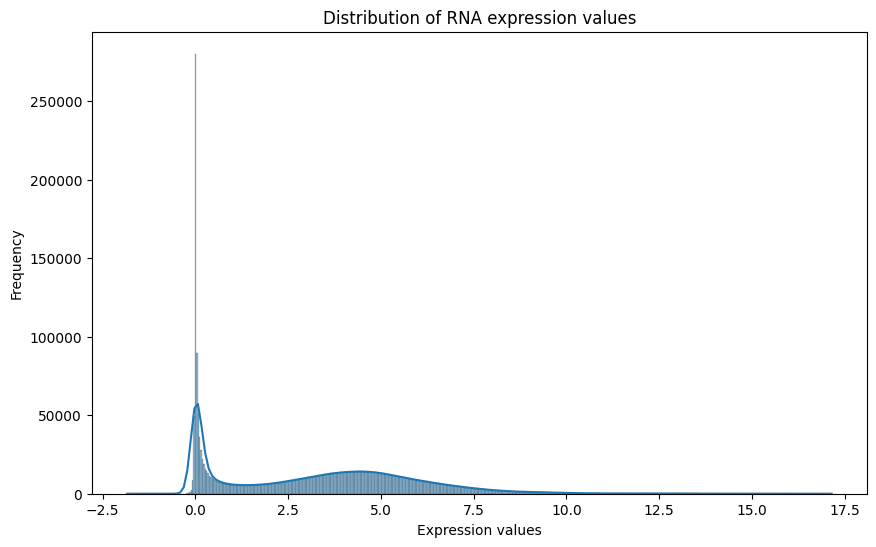

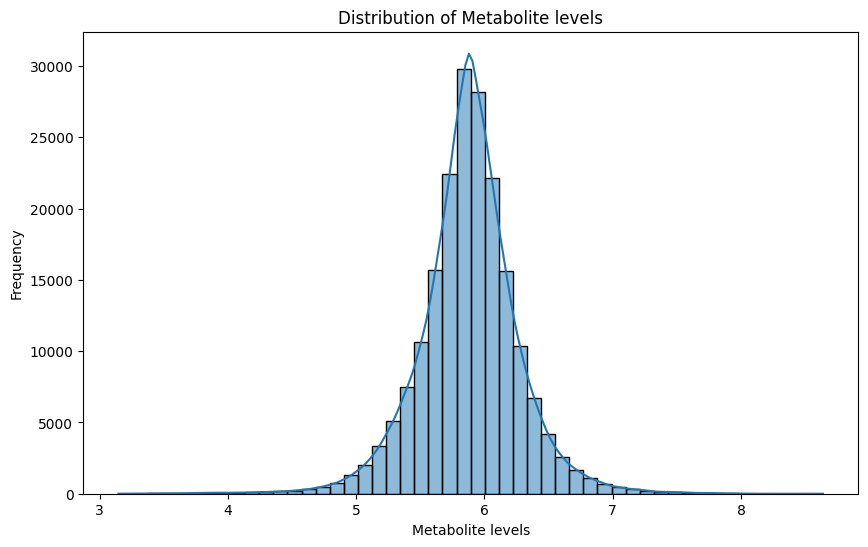

In [14]:
# For RNA data
plt.figure(figsize=(10, 6))
sns.histplot(rna.values.ravel(), bins=500, kde=True)
plt.title("Distribution of RNA expression values")
plt.xlabel("Expression values")
plt.ylabel("Frequency")
plt.savefig(f'{results_path}/rna_sample_distribution.svg', bbox_inches = 'tight')
plt.show()

# For metabolite data
plt.figure(figsize=(10, 6))
sns.histplot(metabolites.values.ravel(), bins=50, kde=True)
plt.title("Distribution of Metabolite levels")
plt.xlabel("Metabolite levels")
plt.ylabel("Frequency")
plt.savefig(f'{results_path}/metabolite_sample_distribution.svg', bbox_inches = 'tight')
plt.show()

#Splitting data

In [ ]:
metabolites = metabolites.dropna(axis=1, how='all')
metabolites

,2-aminoadipate,3-phosphoglycerate,alpha-glycerophosphate,4-pyridoxate,aconitate,adenine,adipate,alpha-ketoglutarate,AMP,citrate,...,C56:8 TAG,C56:7 TAG,C56:6 TAG,C56:5 TAG,C56:4 TAG,C56:3 TAG,C56:2 TAG,C58:8 TAG,C58:7 TAG,C58:6 TAG
ACH-000077,5.458940,6.069382,6.877274,6.068750,5.505403,5.933708,5.984277,6.040722,6.683792,5.538999,...,6.245231,6.339022,6.719602,6.448586,6.265289,6.207153,5.872111,6.768072,6.479443,6.610730
ACH-000209,5.724883,5.528589,5.190217,6.269285,5.719527,5.514824,6.001815,5.717462,5.397695,5.647176,...,5.853760,6.508723,6.366569,6.352849,6.366033,6.424799,6.249990,6.471620,6.325426,6.551367
ACH-000056,6.474690,5.993355,5.898925,6.234996,5.175458,6.551271,6.229653,5.676013,6.380704,4.740652,...,6.668476,6.507782,6.815606,6.908637,6.072243,5.822894,5.887173,6.756707,6.739452,6.803388
ACH-000822,6.255503,5.920496,5.064676,5.526682,5.791588,5.087089,5.796132,5.865157,5.507634,6.106123,...,6.231953,6.618700,6.570770,6.327425,6.100676,5.864595,5.736398,6.647899,6.456066,6.401588
ACH-000454,5.774419,5.825809,5.608305,5.521792,6.138877,6.102589,5.821106,6.057658,5.815774,5.953205,...,5.396903,5.808274,5.993829,6.534158,6.338150,6.417696,6.137361,5.638614,6.021500,5.908798
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ACH-000293,5.690023,5.458808,5.296257,5.779547,5.986737,5.928369,5.958596,5.908298,5.794343,5.995080,...,5.497806,5.565710,5.632057,5.441338,5.280388,5.496533,5.490214,5.530708,5.675243,5.833841
ACH-000462,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ACH-000201,6.003538,5.706044,5.326556,6.472264,5.747572,6.017860,5.949465,5.789381,5.673355,5.697559,...,5.794916,6.228368,6.247288,6.509228,6.329372,6.277518,6.559581,6.425130,6.441566,6.329448
ACH-000614,6.081218,6.080584,6.109159,5.865165,6.064304,5.782527,5.614704,6.203720,6.008612,6.078279,...,4.150082,5.962325,5.174400,4.905110,5.517499,5.746800,6.291661,5.357712,5.266682,5.008880


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(rna, metabolites, test_size=0.2, random_state=0)

In [ ]:
from sklearn.impute import SimpleImputer

In [ ]:
imputer_train = SimpleImputer(strategy='mean')
y_train_imputed = imputer_train.fit_transform(y_train)

In [ ]:
imputer_test = SimpleImputer(strategy='mean')
y_test_imputed = imputer_test.fit_transform(y_test)

In [ ]:
y_train = pd.DataFrame(y_train_imputed, columns=y_train.columns, index=y_train.index)
y_test = pd.DataFrame(y_test_imputed, columns=y_test.columns, index=y_test.index)

In [ ]:
if y_train.isnull().any().any():
    print("DataFrame contains NaN values")
else:
    print("DataFrame does not contain NaN values")

DataFrame does not contain NaN values


In [ ]:
if y_test.isnull().any().any():
    print("DataFrame contains NaN values")
else:
    print("DataFrame does not contain NaN values")

DataFrame does not contain NaN values


In [ ]:
y_train_features = y_train.columns
y_train_features

Index(['2-aminoadipate', '3-phosphoglycerate', 'alpha-glycerophosphate',
       '4-pyridoxate', 'aconitate', 'adenine', 'adipate',
       'alpha-ketoglutarate', 'AMP', 'citrate',
       ...
       'C56:8 TAG', 'C56:7 TAG', 'C56:6 TAG', 'C56:5 TAG', 'C56:4 TAG',
       'C56:3 TAG', 'C56:2 TAG', 'C58:8 TAG', 'C58:7 TAG', 'C58:6 TAG'],
      dtype='object', length=225)

In [ ]:
import pickle

# Save the list to a file
with open(f'{results_path}/y_train_features.pkl', 'wb') as f:
    pickle.dump(y_train_features, f)

#Import sklearn modules

In [ ]:
!pip install xgboost

In [ ]:
!pip install lightgbm

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import MultiTaskLasso
from sklearn.linear_model import MultiTaskElasticNet
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import Ridge

/usr/local/lib/python3.11/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


#Scoring and plotting functions

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error

def get_r2_mse_rmse_plot_pred(data_y_test, model_predictions, model_type):

  r2 = r2_score(data_y_test, model_predictions)
  mse = mean_squared_error(data_y_test, model_predictions)
  rmse = mse**0.5

  print(f"R-squared: {r2}")
  print(f"Mean Squared Error (MSE): {mse}")
  print(f"Root Mean Squared Error (RMSE): {rmse}")


  plt.figure(figsize=(8, 6))
  for i in range(data_y_test.shape[1]):
      plt.scatter(data_y_test.iloc[:, i], model_predictions[:, i], alpha=0.5)

  plt.plot([data_y_test.min().min(), data_y_test.max().max()], [data_y_test.min().min(), data_y_test.max().max()], 'k--', lw=2, label='Ideal')

  plt.xlabel("Actual Values")
  plt.ylabel("Predicted Values")
  plt.title(f"Predicted vs. Actual Values for Metabolites ({model_type})")
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper right')
  plt.grid(True)
  plt.savefig(f'{results_path}/{model_type}.svg', bbox_inches = 'tight')
  plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

def plot_cv_scores(model_pipeline, model_type,cv_fold):

  imputer_metabolites = SimpleImputer(strategy='mean')
  metabolites_imputed = imputer_metabolites.fit_transform(metabolites)
  metabolites_imputed = pd.DataFrame(metabolites_imputed, columns=metabolites.columns, index=metabolites.index)

  scores = cross_val_score(model_pipeline, rna, metabolites_imputed, cv=cv_fold, scoring='neg_mean_squared_error', n_jobs = -1)

  print("Cross-validation scores:", scores)
  print("Average score:", scores.mean())

  scores = pd.DataFrame(scores)
  scores = scores.rename(columns = {0: 'Cross-validation scores'})
  scores['Cross-validation fold'] = [i + 1 for i in range(len(scores))]

  sns.lineplot(data = scores, x = 'Cross-validation fold', y = 'Cross-validation scores')
  plt.ylabel('Negative MSE')
  plt.title('Negative MSE fluctuation with CV-fold')
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
  plt.savefig(f'{results_path}/MSE vs CV ({model_type}).svg', bbox_inches = 'tight')
  plt.show()

In [ ]:
from sklearn.model_selection import KFold

def get_r2_cross_val(model, model_name):

  cv = KFold(n_splits=10, shuffle=True, random_state=0)

  scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='r2', n_jobs = -1)

  print("Cross-validation R-squared scores:", scores)
  print("Average R-squared score:", scores.mean())

  scores_df = pd.DataFrame({'Fold': range(1, len(scores) + 1), 'R-squared': scores})

  # Plot the scores
  plt.figure(figsize=(8, 6))
  sns.lineplot(x='Fold', y='R-squared', data=scores_df, marker='o')
  plt.title(f'Cross-validation R-squared scores for {model_name}')
  plt.xlabel('Fold')
  plt.ylabel('R-squared')
  plt.savefig(f'{results_path}/R2 vs CV ({model_name}).svg', bbox_inches = 'tight')
  plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error

def get_metrics(y_predicted):

  mse = mean_squared_error(y_test, y_predicted)
  print("MSE:", mse)

  from sklearn.metrics import mean_absolute_error
  mae = mean_absolute_error(y_test, y_predicted)
  print("MAE:", mae)

  from sklearn.metrics import median_absolute_error
  medae = median_absolute_error(y_test, y_predicted,)
  print("MedAE:", medae)

  def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

  mape = mean_absolute_percentage_error(y_test, y_predicted)
  print('Mean absolute percentage error:', mape)

In [ ]:
from scipy.stats import spearmanr

def get_spearman_correlation(model_predictions, model_name):

  correlation, p_value = spearmanr(X_test, model_predictions)

  correlation_df = pd.DataFrame({'Actual': y_test.values.flatten(), 'Predicted': model_predictions.flatten()})

  # Calculate Spearman's correlation
  correlation, p_value = spearmanr(correlation_df['Actual'], correlation_df['Predicted'])

  # Add correlation and p-value to DataFrame
  correlation_df['Correlation'] = correlation
  correlation_df['P-value'] = p_value

  sns.regplot(x='Actual', y='Predicted', data=correlation_df, line_kws={'color': 'red'})
  plt.title(f'Spearman\'s Correlation ({model_name})')
  plt.xlabel('Actual Values')
  plt.ylabel('Predicted Values')

  # Add correlation and p-value as text
  plt.text(0.1, 0.9, f'Correlation: {correlation:.2f}\nP-value: {p_value:.2f}', transform=plt.gca().transAxes)
  plt.savefig(f'{results_path}/Spearmans Corr ({model_name}).svg', bbox_inches = 'tight')
  plt.show()

In [ ]:
#Checking for heteroscedasticity
!pip install statsmodels

import statsmodels.api as sm

def get_residuals_vs_pred_plot(model_predictions, model_name):

  residuals = (y_test - model_predictions).values.ravel()

  plt.figure(figsize=(8, 6))
  plt.scatter(model_predictions.ravel(), residuals, alpha=0.6)
  plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
  plt.title(f"Residuals vs. Predicted Values ({model_name})")
  plt.xlabel("Predicted Values")
  plt.ylabel("Residuals")
  plt.savefig(f'{results_path}/Residuals vs Pred Values ({model_name}).svg', bbox_inches = 'tight')
  plt.show()

In [ ]:
def plot_r2_per_metabolite(model, model_name, X_test, y_test):
    """Plots the R2 score per metabolite for a given model in descending order."""

    y_pred = model.predict(X_test)  # Get model predictions

    r2_scores = []  # Initialize list to store R2 scores
    for i in range(y_test.shape[1]):  # Iterate through each metabolite (column)
        r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])  # Calculate R2 for the current metabolite
        r2_scores.append(r2)  # Add the R2 score to the list

    # Create a DataFrame for sorting
    r2_df = pd.DataFrame({'Metabolite': y_test.columns, 'R2 Score': r2_scores})

    # Sort the DataFrame by R2 scores in descending order
    r2_df = r2_df.sort_values(by=['R2 Score'], ascending=False)

    # Plotting
    plt.figure(figsize=(10, 6))  # Adjust figure size as needed
    plt.bar(range(len(r2_df)), r2_df['R2 Score'])  # Create bar plot of R2 scores
    plt.xticks()  # Set x-axis labels to metabolite names
    plt.xlabel("Metabolite")
    plt.ylabel("R2 Score")
    plt.title(f"R2 Score per Metabolite ({model_name}) - Descending Order")
    plt.tight_layout()  # Adjust layout to prevent labels from overlapping
    plt.savefig(f'{results_path}/R2 per metabolite ({model_name}).svg', bbox_inches = 'tight')
    plt.show()

In [ ]:
def get_r2_per_metabolite(model, model_name, X_test, y_test):
    """Get the R2 score per metabolite for a given model in descending order."""

    y_pred = model.predict(X_test)  # Get model predictions

    r2_scores = []  # Initialize list to store R2 scores
    for i in range(y_test.shape[1]):  # Iterate through each metabolite (column)
        r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])  # Calculate R2 for the current metabolite
        r2_scores.append(r2)  # Add the R2 score to the list

    # Create a DataFrame for sorting
    r2_df = pd.DataFrame({'Metabolite': y_test.columns, 'R2 Score': r2_scores})

    # Sort the DataFrame by R2 scores in descending order
    r2_df = r2_df.sort_values(by=['R2 Score'], ascending=False)

    return r2_df

In [ ]:
from scipy.stats import spearmanr

def plot_spearman_per_metabolite(model, model_name, X_test, y_test):
    """Plots the Spearman's correlation coefficient per metabolite for a given model."""

    y_pred = model.predict(X_test)  # Get model predictions

    spearman_coeffs = []  # Initialize list to store Spearman's coefficients
    for i in range(y_test.shape[1]):  # Iterate through each metabolite (column)
        coeff, _ = spearmanr(y_test.iloc[:, i], y_pred[:, i])  # Calculate Spearman's coefficient
        spearman_coeffs.append(coeff)  # Add the coefficient to the list

    # Create a DataFrame for sorting
    spearman_df = pd.DataFrame({'Metabolite': y_test.columns, 'Spearman Coefficient': spearman_coeffs})

    # Sort the DataFrame by Spearman's coefficients in descending order
    spearman_df = spearman_df.sort_values(by=['Spearman Coefficient'], ascending=False)

    # Plotting
    plt.figure(figsize=(10, 6))  # Adjust figure size as needed
    plt.bar(range(len(spearman_df)), spearman_df['Spearman Coefficient'])  # Create bar plot of coefficients
    plt.xticks()  # Set x-axis labels to metabolite names
    plt.xlabel("Metabolite")
    plt.ylabel("Spearman's Coefficient")
    plt.title(f"Spearman's Correlation Coefficient per Metabolite ({model_name}) - Descending Order")
    plt.tight_layout()  # Adjust layout to prevent labels from overlapping
    plt.savefig(f'{results_path}/Spearman per metabolite ({model_name}).svg', bbox_inches = 'tight')
    plt.show()

In [ ]:
def get_spearman_per_metabolite(model, model_name, X_test, y_test):
    """Get the Spearman's correlation coefficient per metabolite for a given model."""

    y_pred = model.predict(X_test)  # Get model predictions

    spearman_coeffs = []  # Initialize list to store Spearman's coefficients
    for i in range(y_test.shape[1]):  # Iterate through each metabolite (column)
        coeff, _ = spearmanr(y_test.iloc[:, i], y_pred[:, i])  # Calculate Spearman's coefficient
        spearman_coeffs.append(coeff)  # Add the coefficient to the list

    # Create a DataFrame for sorting
    spearman_df = pd.DataFrame({'Metabolite': y_test.columns, 'Spearman Coefficient': spearman_coeffs})

    # Sort the DataFrame by Spearman's coefficients in descending order
    spearman_df = spearman_df.sort_values(by=['Spearman Coefficient'], ascending=False)

    return spearman_df

In [ ]:
import joblib

def save_model(model, model_name):
    joblib.dump(model, f'{results_path}/{model_name}.pkl')

#Ridge

In [ ]:
pipeline_ridge = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('pca', PCA(0.95,)),
    ('model', Ridge(random_state = 0))
                          ])

In [ ]:
param_grid_ridge = {
    'model__alpha' : [4500, 5000, 6000, 6050, 6075, 6100, 6125, 6150, 6175, 6250, 6500, 7000]
}

In [ ]:
grid_search_ridge = GridSearchCV(
    pipeline_ridge,
    param_grid_ridge,
    cv = 5,
    scoring = 'neg_mean_squared_error',
    n_jobs = -1
)

grid_search_ridge.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('imputer', SimpleImputer()),
                                       ('scaler', StandardScaler()),
                                       ('pca', PCA(n_components=0.95)),
                                       ('model', Ridge(random_state=0))]),
             n_jobs=-1,
             param_grid={'model__alpha': [4500, 5000, 6000, 6050, 6075, 6100,
                                          6125, 6150, 6175, 6250, 6500, 7000]},
             scoring='neg_mean_squared_error')

In [ ]:
print("Best hyperparameters:", grid_search_ridge.best_params_)
print("Best score:", grid_search_ridge.best_score_)

Best hyperparameters: {'model__alpha': 6150}
Best score: -0.11467476053045049


In [ ]:
best_ridge_model = grid_search_ridge.best_estimator_

In [ ]:
save_model(model = best_ridge_model, model_name = 'Ridge')

In [ ]:
ridge_predictions = best_ridge_model.predict(X_test)

Cross-validation scores: [-0.11197254 -0.11573803 -0.11500916 -0.11400552 -0.10614344 -0.11564164
 -0.12172431 -0.10967756 -0.11551591 -0.11071652]
Average score: -0.11361446398413085


<ipython-input-29-a43c56a4846a>:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


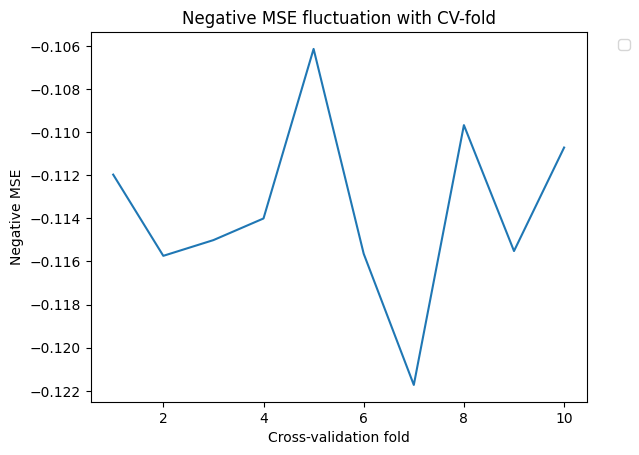

In [ ]:
plot_cv_scores(model_pipeline = best_ridge_model, model_type = 'Ridge', cv_fold = 10)

R-squared: 0.17660780854922148
Mean Squared Error (MSE): 0.10965454803279225
Root Mean Squared Error (RMSE): 0.3311412810762081


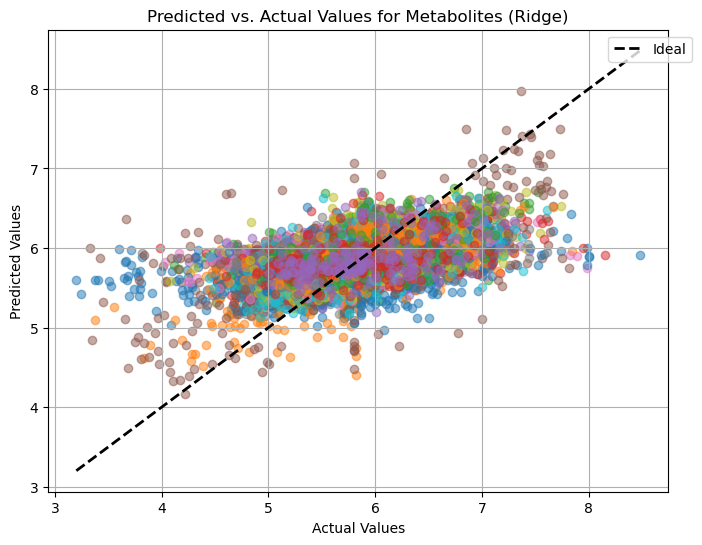

In [ ]:
get_r2_mse_rmse_plot_pred(data_y_test = y_test, model_predictions = ridge_predictions, model_type = 'Ridge')

Cross-validation R-squared scores: [0.18060842 0.145097   0.15445148 0.15763425 0.17629079 0.16454992
 0.11966934 0.13721837 0.11422616 0.18448264]
Average R-squared score: 0.15342283820850824


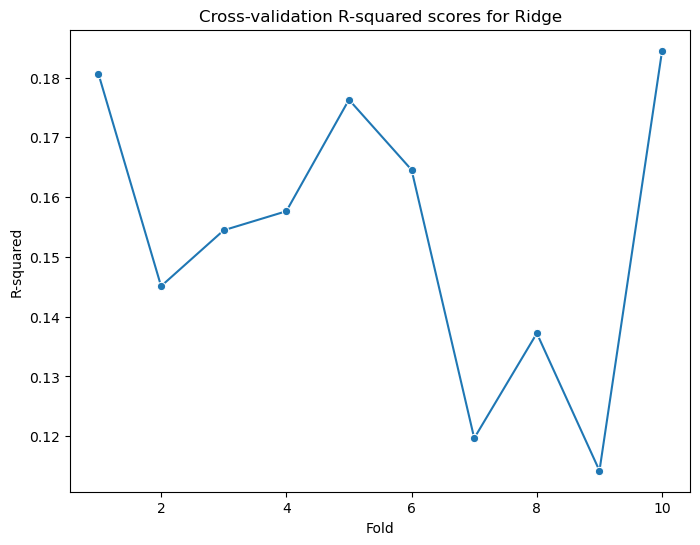

In [ ]:
get_r2_cross_val(model = best_ridge_model, model_name = 'Ridge')

In [ ]:
get_metrics(y_predicted = ridge_predictions)

MSE: 0.10965454803279225
MAE: 0.2402878837302309
MedAE: 0.19526449490979308
Mean absolute percentage error: 4.144965549738891


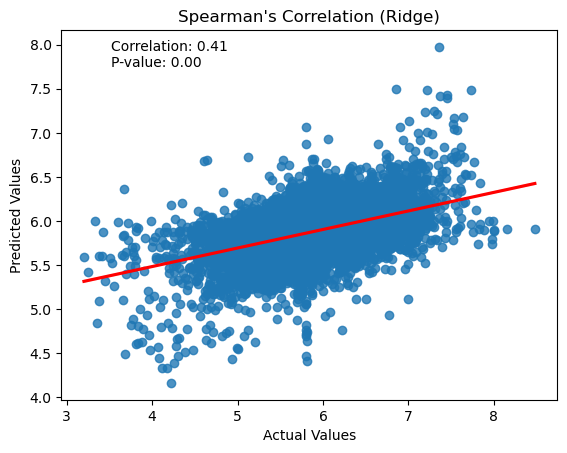

In [ ]:
get_spearman_correlation(model_predictions = ridge_predictions, model_name = 'Ridge')

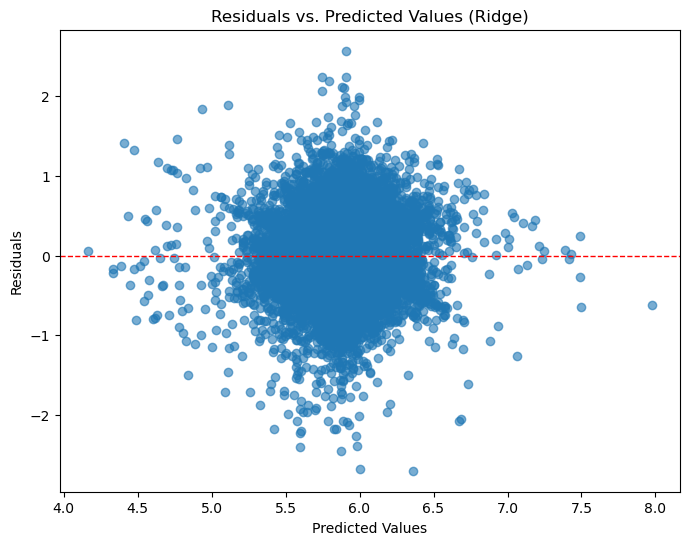

In [ ]:
get_residuals_vs_pred_plot(model_predictions = ridge_predictions, model_name = 'Ridge')

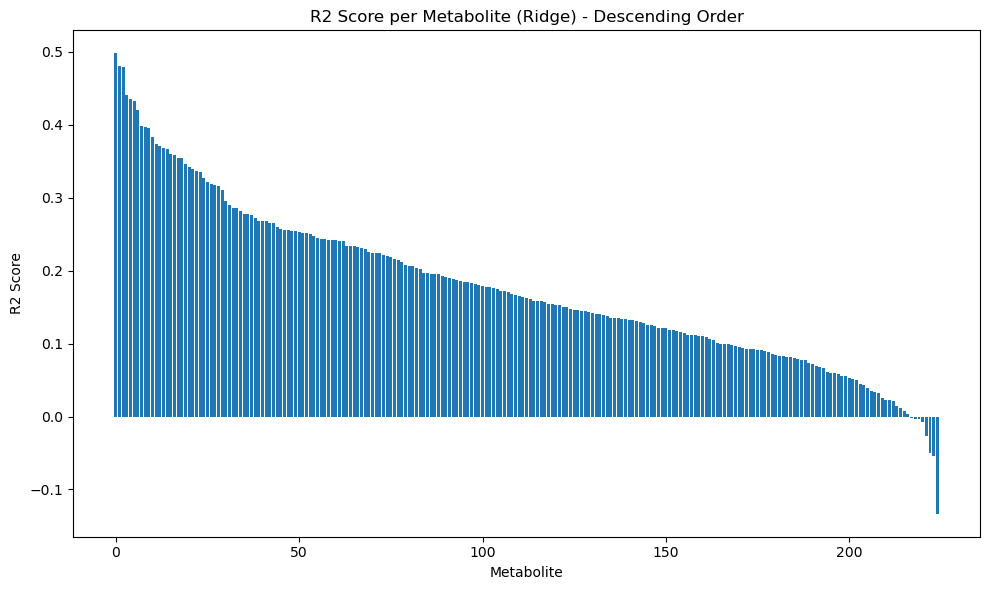

In [ ]:
plot_r2_per_metabolite(best_ridge_model, "Ridge", X_test, y_test)

In [ ]:
r2_ridge = get_r2_per_metabolite(best_ridge_model, 'Ridge', X_test, y_test)
r2_ridge

,Metabolite,R2 Score
115,1-methylnicotinamide,0.614567
51,phosphocreatine,0.500982
188,C20:5 CE,0.423003
189,C20:4 CE,0.394206
186,C18:1 CE,0.377376
...,...,...
16,erythrose-4-phosphate,-0.042653
86,homocysteine,-0.052971
82,serotonin,-0.061540
50,taurodeoxycholate/taurochenodeoxycholate,-0.061846


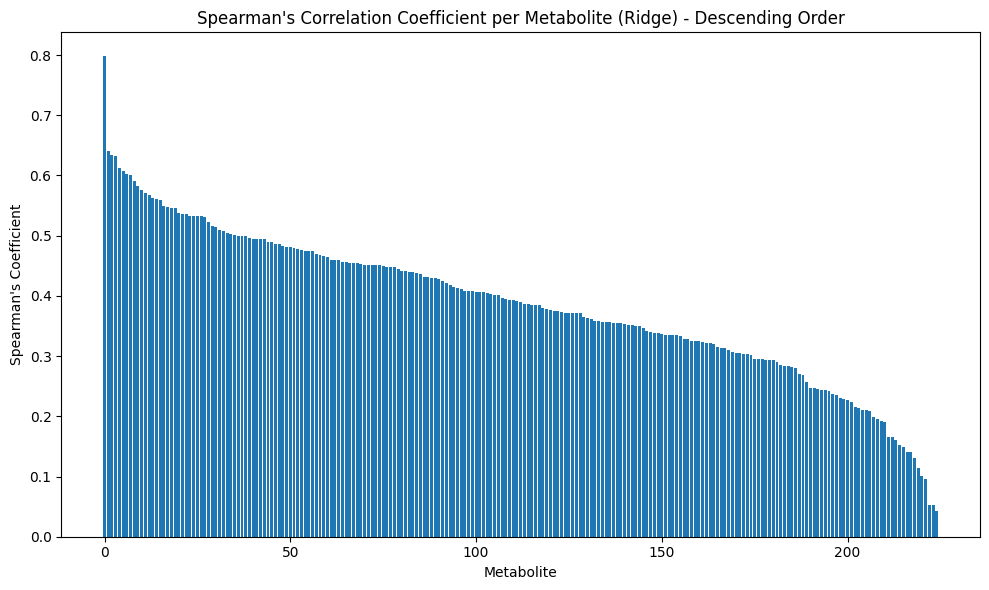

In [ ]:
plot_spearman_per_metabolite(best_ridge_model, 'Ridge', X_test, y_test)

In [ ]:
spearman_ridge = get_spearman_per_metabolite(best_ridge_model, 'Ridge', X_test, y_test)
spearman_ridge

,Metabolite,Spearman Coefficient
115,1-methylnicotinamide,0.797898
51,phosphocreatine,0.639882
101,creatine,0.634379
188,C20:5 CE,0.631562
190,C20:3 CE,0.611793
...,...,...
57,malondialdehyde,0.101464
65,asparagine,0.096581
82,serotonin,0.052685
16,erythrose-4-phosphate,0.052259


In [ ]:
r2_ridge.to_csv(f'{results_path}/r2_ridge.csv', index = False)

In [ ]:
spearman_ridge.to_csv(f'{results_path}/spearman_ridge.csv', index = False)

#Multi-task Lasso

In [ ]:
pipeline_multi_lasso = Pipeline([
                                ('imputer', SimpleImputer(strategy='mean')),
                                ('scaler', StandardScaler()),
                                ('pca', PCA(0.95,)),
                                ('model', MultiTaskLasso(random_state = 0))
                                ])

In [ ]:
param_grid_lasso = {
                    'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100] # Example values for alpha
                   }

grid_search_lasso = GridSearchCV(pipeline_multi_lasso, param_grid_lasso, cv=10, scoring='neg_mean_squared_error', n_jobs = -1)
grid_search_lasso.fit(X_train, y_train)

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('imputer', SimpleImputer()),
                                       ('scaler', StandardScaler()),
                                       ('pca', PCA(n_components=0.95)),
                                       ('model',
                                        MultiTaskLasso(random_state=0))]),
             n_jobs=-1,
             param_grid={'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100]},
             scoring='neg_mean_squared_error')

In [ ]:
print("Best hyperparameters:", grid_search_lasso.best_params_)
print("Best score:", grid_search_lasso.best_score_)

Best hyperparameters: {'model__alpha': 1}
Best score: -0.11875030741476292


In [ ]:
best_lasso_model = grid_search_lasso.best_estimator_

In [ ]:
save_model(model = best_lasso_model, model_name = 'Lasso')

In [ ]:
lasso_predictions = best_lasso_model.predict(X_test)

Cross-validation scores: [-0.11326571 -0.12158086 -0.11916526 -0.12530793 -0.11386882 -0.11769531
 -0.11919485 -0.12126059 -0.11987037 -0.11754059]
Average score: -0.11887502970959729


C:\Users\tkaralis\AppData\Local\Temp\ipykernel_7976\2128722762.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


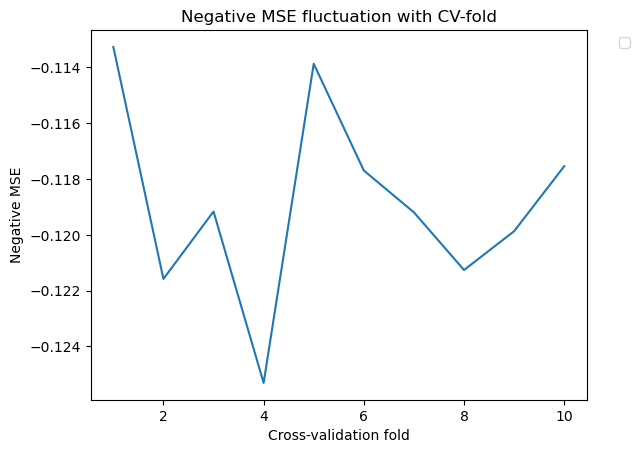

In [ ]:
plot_cv_scores(model_pipeline = best_lasso_model, model_type = 'Multi-task Lasso', cv_fold = 10)

R-squared: 0.14766464627233228
Mean Squared Error (MSE): 0.1144736514265841
Root Mean Squared Error (RMSE): 0.3383395504911953


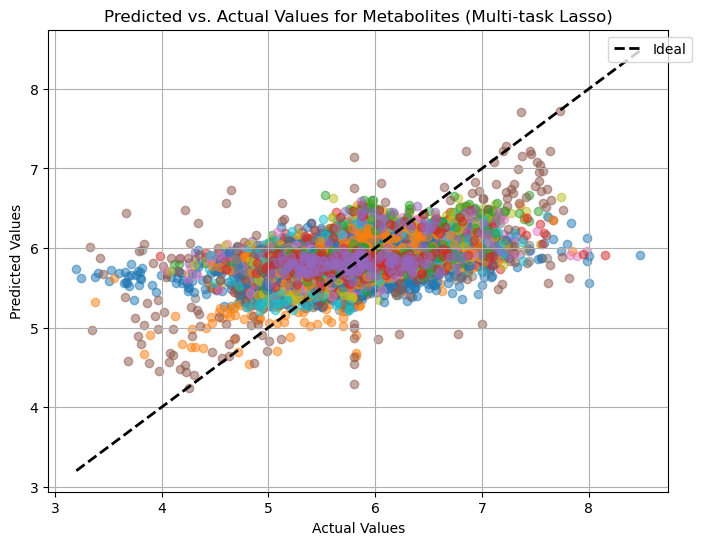

In [ ]:
get_r2_mse_rmse_plot_pred(data_y_test = y_test, model_predictions = lasso_predictions, model_type = 'Multi-task Lasso')

Cross-validation R-squared scores: [0.14223205 0.12702684 0.13537958 0.12055629 0.13516155 0.13284916
 0.099479   0.12352664 0.09107092 0.15389756]
Average R-squared score: 0.12611795872911247


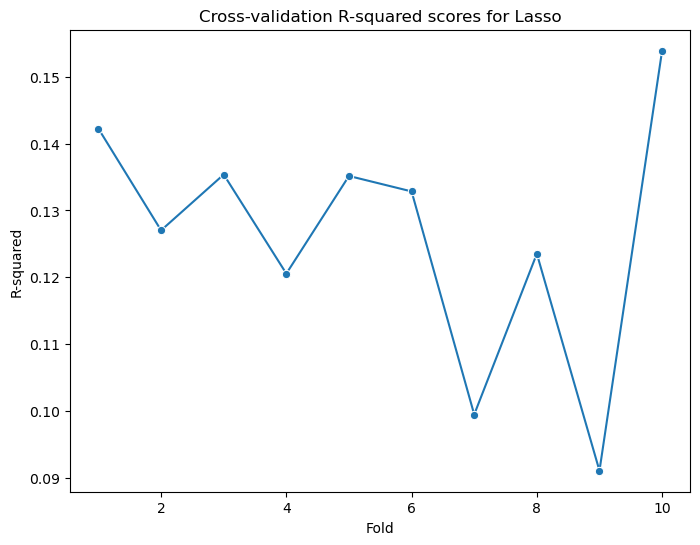

In [ ]:
get_r2_cross_val(model = best_lasso_model, model_name = 'Lasso')

In [ ]:
get_metrics(y_predicted = lasso_predictions)

MSE: 0.1144736514265841
MAE: 0.24438703928903457
MedAE: 0.19745505374782385
Mean absolute percentage error: 4.216378597185245


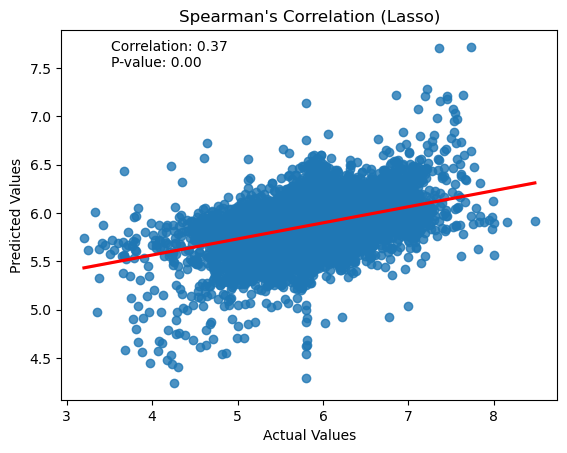

In [ ]:
get_spearman_correlation(model_predictions = lasso_predictions, model_name = 'Lasso')

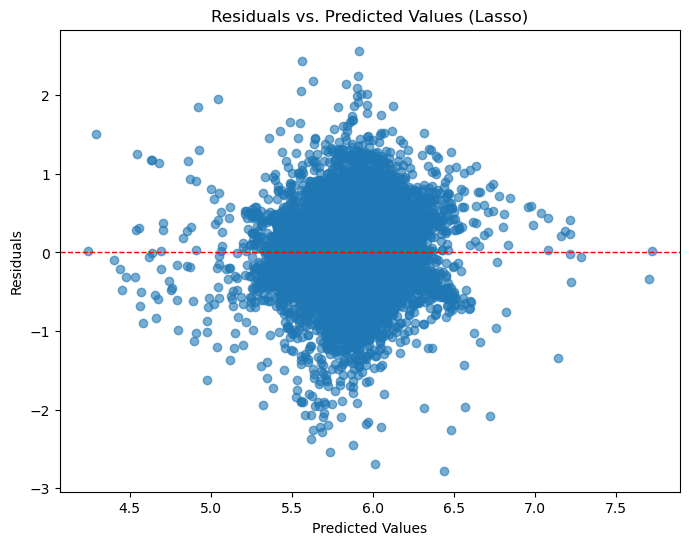

In [ ]:
get_residuals_vs_pred_plot(model_predictions = lasso_predictions, model_name = 'Lasso')

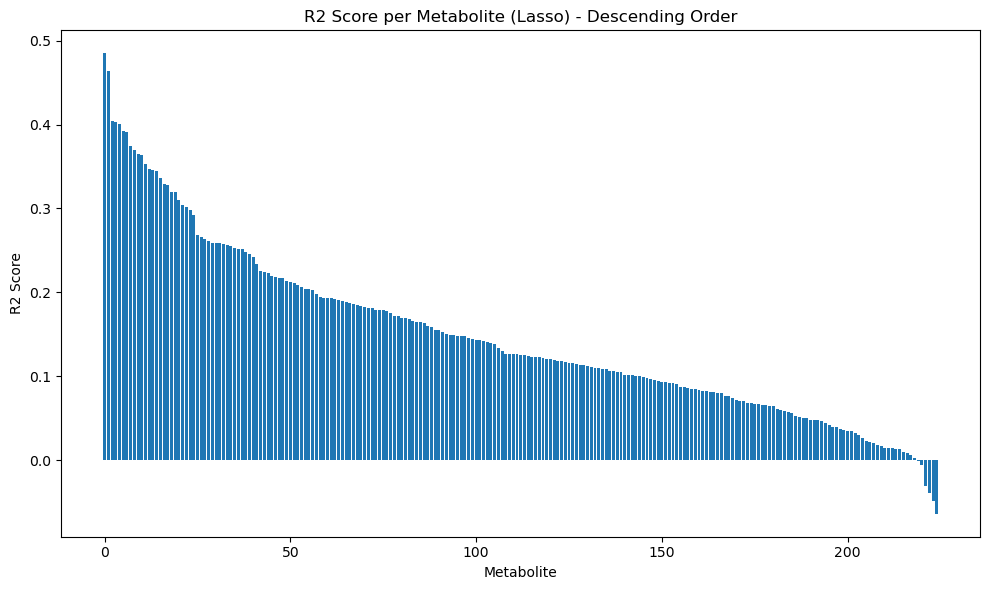

In [ ]:
plot_r2_per_metabolite(best_lasso_model, "Lasso", X_test, y_test)

In [ ]:
r2_lasso = get_r2_per_metabolite(best_lasso_model, 'Lasso', X_test, y_test)
r2_lasso

,Metabolite,R2 Score
115,1-methylnicotinamide,0.563711
51,phosphocreatine,0.422342
188,C20:5 CE,0.399814
189,C20:4 CE,0.389508
91,kynurenic acid,0.352767
...,...,...
82,serotonin,-0.018081
57,malondialdehyde,-0.023613
138,C16:0 LPC,-0.026063
50,taurodeoxycholate/taurochenodeoxycholate,-0.046487


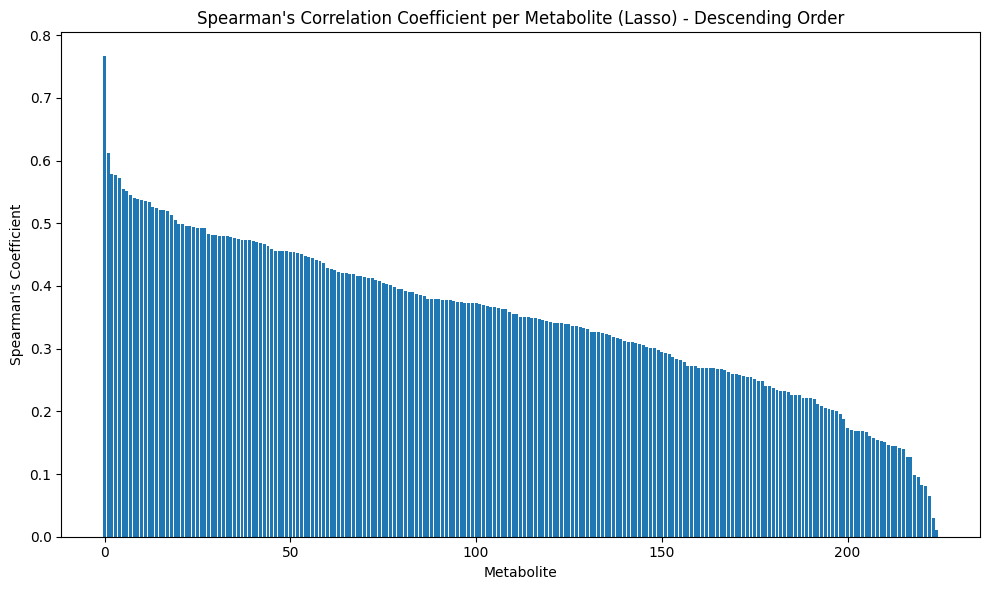

In [ ]:
plot_spearman_per_metabolite(best_lasso_model, 'Lasso', X_test, y_test)

In [ ]:
spearman_lasso = get_spearman_per_metabolite(best_lasso_model, 'Lasso', X_test, y_test)
spearman_lasso

,Metabolite,Spearman Coefficient
115,1-methylnicotinamide,0.766293
188,C20:5 CE,0.612749
42,UMP,0.578582
190,C20:3 CE,0.577726
191,C22:6 CE,0.571576
...,...,...
96,niacinamide,0.082685
82,serotonin,0.080635
31,malate,0.064604
138,C16:0 LPC,0.029446


In [ ]:
r2_lasso.to_csv(f'{results_path}/r2_lasso.csv', index = False)
spearman_lasso.to_csv(f'{results_path}/spearman_lasso.csv', index = False)

#Multi-task Elastic-Net

In [ ]:
pipeline_elasticnet = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('pca', PCA(0.95)),
    ('model', MultiTaskElasticNet(random_state = 0))
])

In [ ]:
param_grid_elasticnet = {
    'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100],
    'model__l1_ratio': [0.1, 0.5, 0.9]
}


In [ ]:
grid_search_elasticnet = GridSearchCV(
                                      pipeline_elasticnet,
                                      param_grid_elasticnet,
                                      cv=10,
                                      scoring='neg_mean_squared_error',
                                      n_jobs = -1
                                      )
grid_search_elasticnet.fit(X_train, y_train)

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('imputer', SimpleImputer()),
                                       ('scaler', StandardScaler()),
                                       ('pca', PCA(n_components=0.95)),
                                       ('model',
                                        MultiTaskElasticNet(random_state=0))]),
             n_jobs=-1,
             param_grid={'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100],
                         'model__l1_ratio': [0.1, 0.5, 0.9]},
             scoring='neg_mean_squared_error')

In [ ]:
print("Best hyperparameters for ElasticNet:", grid_search_elasticnet.best_params_)
print("Best score for ElasticNet:", grid_search_elasticnet.best_score_)

Best hyperparameters for ElasticNet: {'model__alpha': 1, 'model__l1_ratio': 0.5}
Best score for ElasticNet: -0.11574122201084125


In [ ]:
best_elasticnet_model = grid_search_elasticnet.best_estimator_

In [ ]:
save_model(model = best_elasticnet_model, model_name = 'ElasticNet')

In [ ]:
elasticnet_predictions = best_elasticnet_model.predict(X_test)

Cross-validation scores: [-0.10984818 -0.11690455 -0.11584717 -0.12150083 -0.11093874 -0.11378854
 -0.11525331 -0.11847265 -0.11673029 -0.11471704]
Average score: -0.11540012987572805


C:\Users\tkaralis\AppData\Local\Temp\ipykernel_7976\2128722762.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


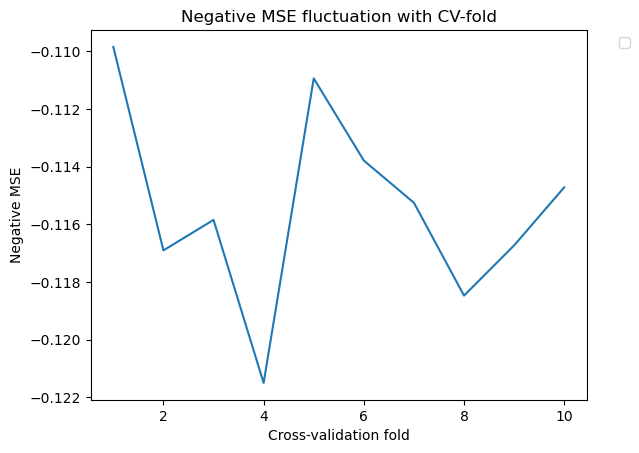

In [ ]:
plot_cv_scores(model_pipeline = best_elasticnet_model, model_type = 'Multi-task Elastic Net (All metabolites)', cv_fold = 10)

R-squared: 0.16838970067040507
Mean Squared Error (MSE): 0.11123808214689096
Root Mean Squared Error (RMSE): 0.3335237355075212


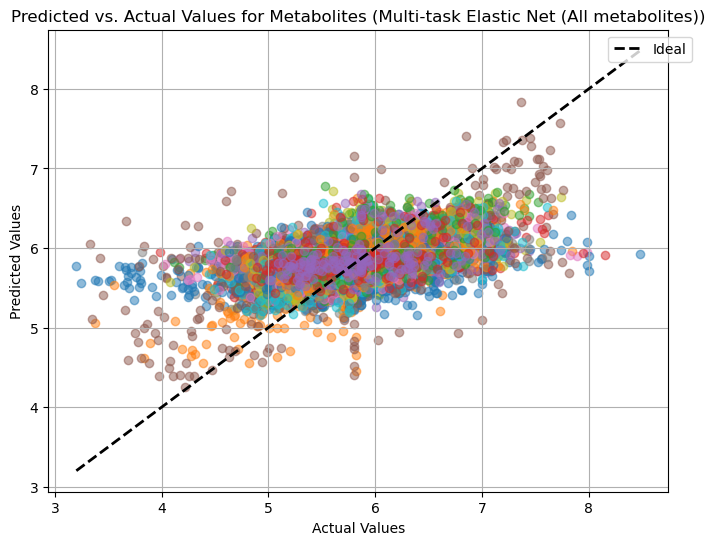

In [ ]:
get_r2_mse_rmse_plot_pred(data_y_test = y_test, model_predictions = elasticnet_predictions, model_type = 'Multi-task Elastic Net (All metabolites)')

Cross-validation R-squared scores: [0.16688671 0.13839417 0.15698805 0.14896771 0.16436761 0.15565267
 0.11013389 0.13681134 0.102871   0.17187593]
Average R-squared score: 0.1452949087386184


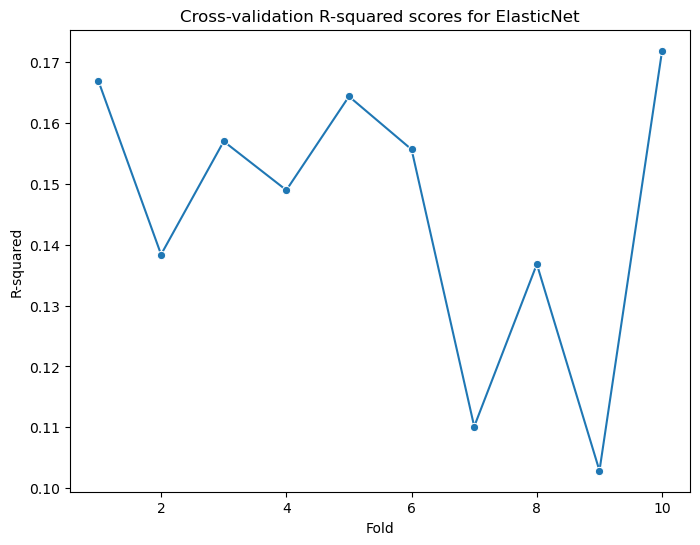

In [ ]:
get_r2_cross_val(model = best_elasticnet_model, model_name = 'ElasticNet')

In [ ]:
get_metrics(y_predicted = elasticnet_predictions)

MSE: 0.11123808214689096
MAE: 0.24125839717184483
MedAE: 0.19466690276527215
Mean absolute percentage error: 4.161909567015133


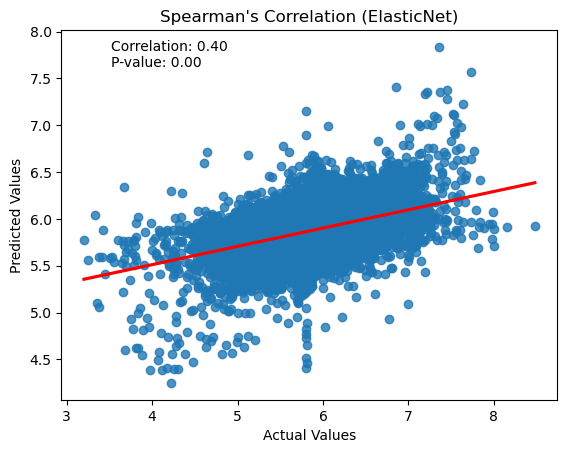

In [ ]:
get_spearman_correlation(model_predictions = elasticnet_predictions, model_name = 'ElasticNet')

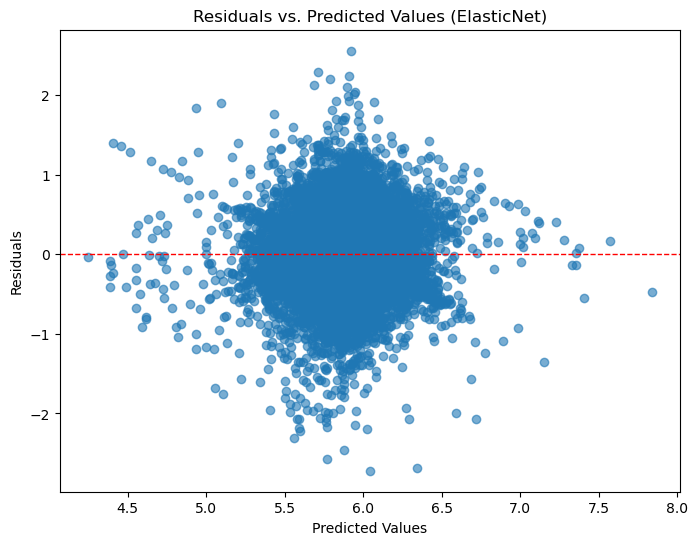

In [ ]:
get_residuals_vs_pred_plot(model_predictions = elasticnet_predictions, model_name = 'ElasticNet')

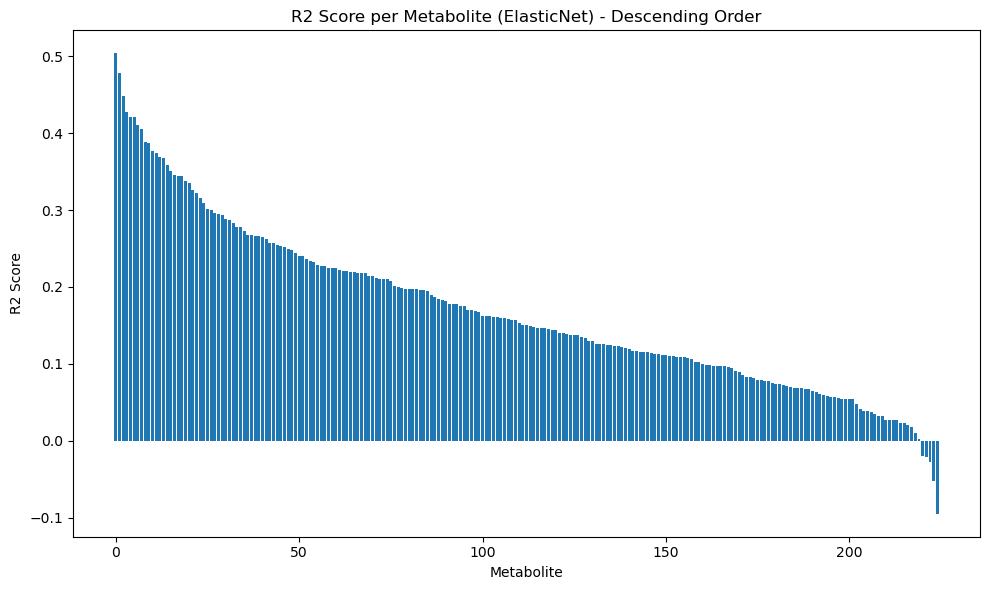

In [ ]:
plot_r2_per_metabolite(best_elasticnet_model, "ElasticNet", X_test, y_test)

In [ ]:
y_test.to_csv(f'{results_path}/y_test_elasticnet_model.csv', index = True)

In [ ]:
elasticnet_predictions = pd.DataFrame(elasticnet_predictions, index = y_test.index, columns = y_test.columns)
elasticnet_predictions

,2-aminoadipate,3-phosphoglycerate,alpha-glycerophosphate,4-pyridoxate,aconitate,adenine,adipate,alpha-ketoglutarate,AMP,citrate,...,C56:8 TAG,C56:7 TAG,C56:6 TAG,C56:5 TAG,C56:4 TAG,C56:3 TAG,C56:2 TAG,C58:8 TAG,C58:7 TAG,C58:6 TAG
ACH-000323,6.178131,5.880176,5.886866,5.931357,5.920885,5.833219,5.898858,5.914012,5.754972,5.866875,...,5.792492,5.834088,5.886527,5.819639,5.779568,5.619815,5.588509,5.818213,5.815061,5.828487
ACH-000542,5.951861,6.001626,5.942180,5.903107,6.011809,5.899050,5.807959,5.976325,5.899331,5.966662,...,5.778094,5.788074,5.762138,5.733550,5.745748,5.825733,5.979791,5.787685,5.755286,5.739708
ACH-000383,5.786208,6.041525,5.727325,5.865427,5.942683,5.815218,5.837276,5.920361,5.856315,5.945038,...,5.778608,5.873445,5.865790,5.861273,5.869103,6.047796,6.071599,5.873377,5.843666,5.820098
ACH-000212,5.993322,5.928520,5.888562,5.871806,5.943791,5.787894,5.819235,5.938997,5.838754,5.928291,...,5.774558,5.801454,5.799650,5.822872,5.834371,5.861801,5.877794,5.808889,5.792607,5.773905
ACH-000501,5.840207,5.842027,5.703250,5.888847,5.888548,5.761193,5.898767,5.799984,5.815488,5.886245,...,5.911816,6.065367,6.007829,5.967576,5.887573,5.899696,5.909091,6.145303,6.055895,6.050529
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ACH-000588,5.901332,5.672345,6.236512,6.115203,5.616408,6.067837,5.949235,5.785280,6.480132,5.595583,...,6.072703,6.124288,6.219947,6.261144,6.163632,6.011363,6.115262,6.307767,6.292185,6.274208
ACH-000035,5.932437,6.012834,5.598370,5.894800,5.936304,5.803048,5.862178,5.935118,5.740683,5.909178,...,5.726144,5.733041,5.728058,5.669540,5.677830,5.761980,5.743209,5.667184,5.671511,5.640458
ACH-000625,5.905594,5.980493,5.927343,5.875944,5.821424,6.013606,5.846706,5.909323,5.767162,5.792629,...,5.760248,5.939342,5.902328,5.996199,6.048084,6.146872,6.105801,5.972408,5.961571,5.907558
ACH-000093,5.769664,5.903933,5.602520,5.996460,5.885073,5.858975,5.880004,5.827653,5.914101,5.971338,...,5.793634,5.820365,5.791210,5.733328,5.700889,5.834452,5.924944,5.799343,5.778828,5.737615


In [ ]:
elasticnet_predictions.to_csv(f'{results_path}/predictions_elasticnet_model.csv', index = True)

In [ ]:
r2_elastic = get_r2_per_metabolite(best_elasticnet_model, 'ElasticNet', X_test, y_test)
r2_elastic

,Metabolite,R2 Score
115,1-methylnicotinamide,0.604839
51,phosphocreatine,0.465894
188,C20:5 CE,0.405979
189,C20:4 CE,0.385566
186,C18:1 CE,0.354668
...,...,...
113,pipecolic acid,-0.030390
16,erythrose-4-phosphate,-0.038186
82,serotonin,-0.040171
57,malondialdehyde,-0.048696


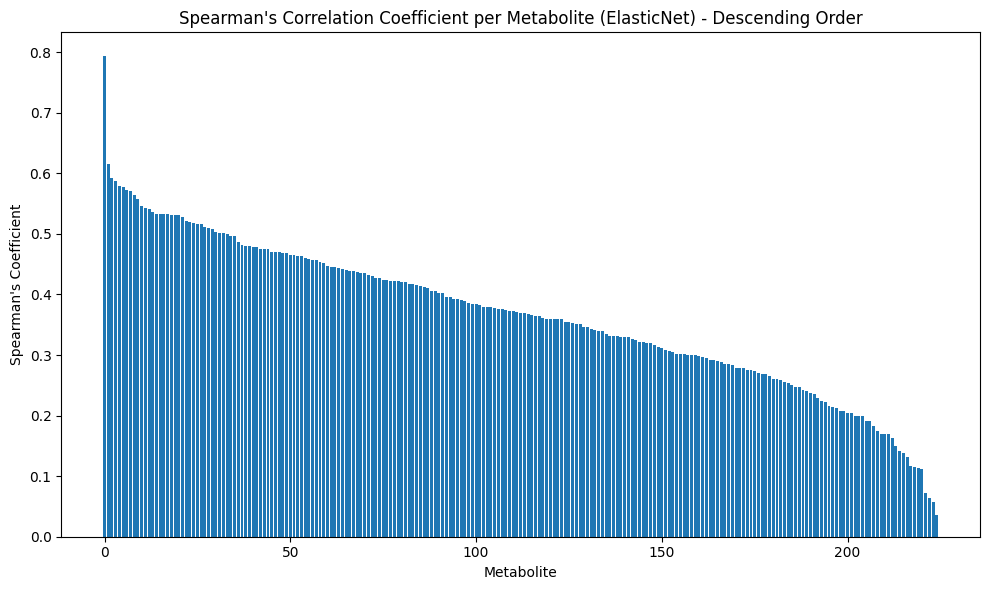

In [ ]:
plot_spearman_per_metabolite(best_elasticnet_model, 'ElasticNet', X_test, y_test)

In [ ]:
spearman_elastic = get_spearman_per_metabolite(best_elasticnet_model, 'ElasticNet', X_test, y_test)
spearman_elastic

,Metabolite,Spearman Coefficient
115,1-methylnicotinamide,0.793128
188,C20:5 CE,0.615472
51,phosphocreatine,0.592942
190,C20:3 CE,0.587497
101,creatine,0.579696
...,...,...
65,asparagine,0.112588
96,niacinamide,0.071427
82,serotonin,0.063826
16,erythrose-4-phosphate,0.056816


In [ ]:
r2_elastic.to_csv(f'{results_path}/r2_elastic.csv', index = False)
spearman_elastic.to_csv(f'{results_path}/spearman_elastic.csv', index = False)

#Random Forest Regressor

In [ ]:
pipeline_rf = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('pca', PCA(0.95)),
    ('model', MultiOutputRegressor(RandomForestRegressor(n_estimators = 500, max_depth = 20, random_state=0, n_jobs = -1)))
])

In [ ]:
model_rf = pipeline_rf.fit(X_train, y_train)

In [ ]:
# pipeline_rf = Pipeline([
#     ('imputer', SimpleImputer(strategy='mean')),
#     ('scaler', StandardScaler()),
#     ('pca', PCA(0.95)),
#     ('model', MultiOutputRegressor(RandomForestRegressor(random_state=0, n_jobs = -1), n_jobs = -1))
# ])

In [ ]:
# rf_param_grid = {
#     'model__estimator__n_estimators' : [100, 150, 200, 250, 300, 500],
#     'model__estimator__max_depth': [5, 10, 20, 30, 50]
# }

In [ ]:
# grid_search_rf = GridSearchCV(
#                               pipeline_rf,
#                               rf_param_grid,
#                               cv = 5,
#                               scoring = 'neg_mean_squared_error',
#                               verbose = 3,
#                               n_jobs = -1
#                               )

In [ ]:
# grid_search_rf.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('imputer', SimpleImputer()),
                                       ('scaler', StandardScaler()),
                                       ('pca', PCA(n_components=0.95)),
                                       ('model',
                                        MultiOutputRegressor(estimator=RandomForestRegressor(n_jobs=-1,
                                                                                             random_state=0),
                                                             n_jobs=-1))]),
             n_jobs=-1,
             param_grid={'model__estimator__max_depth': [5, 10, 20, 30, 50],
                         'model__estimator__n_estimators': [100, 150, 200, 250,
                                                            300, 500]},
             scoring='neg_mean_squared_error', verbose=3)

In [ ]:
# print("Best hyperparameters:", grid_search_rf.best_params_)
# print("Best score:", grid_search_rf.best_score_)

Best hyperparameters: {'model__estimator__max_depth': 20, 'model__estimator__n_estimators': 500}
Best score: -0.12350842203562203


In [ ]:
# model_rf = grid_search_rf.best_estimator_

In [ ]:
save_model(model = model_rf, model_name = 'Random Forest Regressor')

In [ ]:
predictions_rf = model_rf.predict(X_test)

R-squared: 0.12461458495581641
Mean Squared Error (MSE): 0.11792292949516045
Root Mean Squared Error (RMSE): 0.34339908196610025


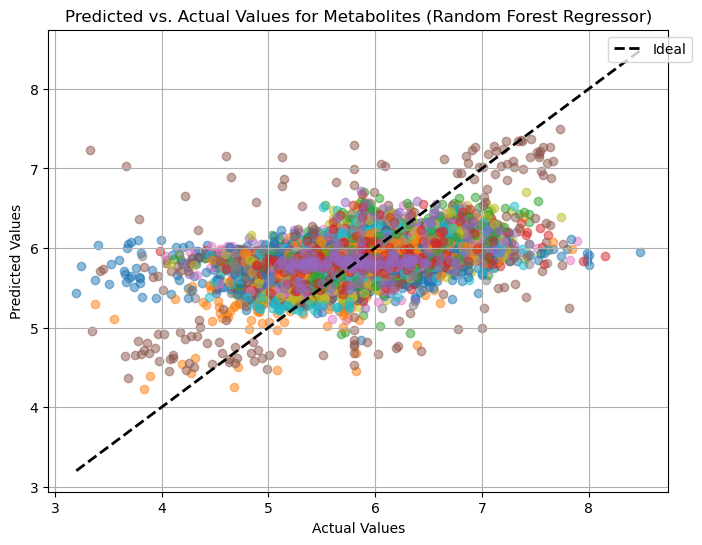

In [ ]:
get_r2_mse_rmse_plot_pred(data_y_test = y_test, model_predictions = predictions_rf, model_type = 'Random Forest Regressor')

Cross-validation scores: [-0.11376634 -0.12413099 -0.12275382 -0.12580435 -0.11615534 -0.12076914
 -0.12178249 -0.12448115 -0.12250062 -0.12116224]
Average score: -0.12133064677451377


C:\Users\tkaralis\AppData\Local\Temp\ipykernel_7976\2128722762.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


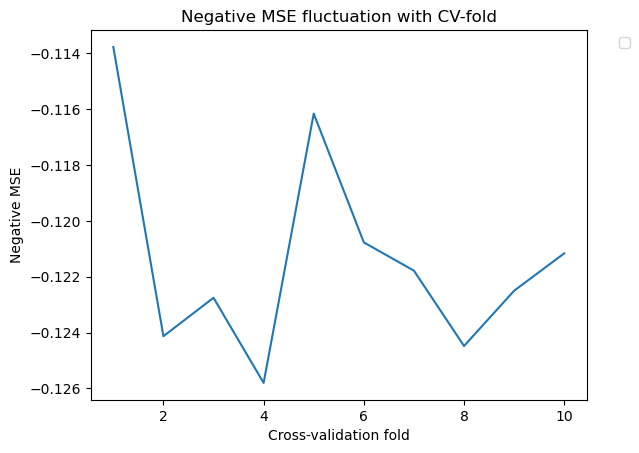

In [ ]:
plot_cv_scores(model_pipeline = model_rf, model_type = 'Multi-output Random Forest Regressor', cv_fold = 10)

In [ ]:
get_metrics(y_predicted = predictions_rf)

MSE: 0.11792292949516045
MAE: 0.2461027102737739
MedAE: 0.19664772387744064
Mean absolute percentage error: 4.247439666733635


Cross-validation R-squared scores: [0.13557769 0.10374437 0.11921377 0.0924986  0.11025345 0.12649237
 0.07684599 0.11668439 0.07196615 0.14382958]
Average R-squared score: 0.10971063538280017


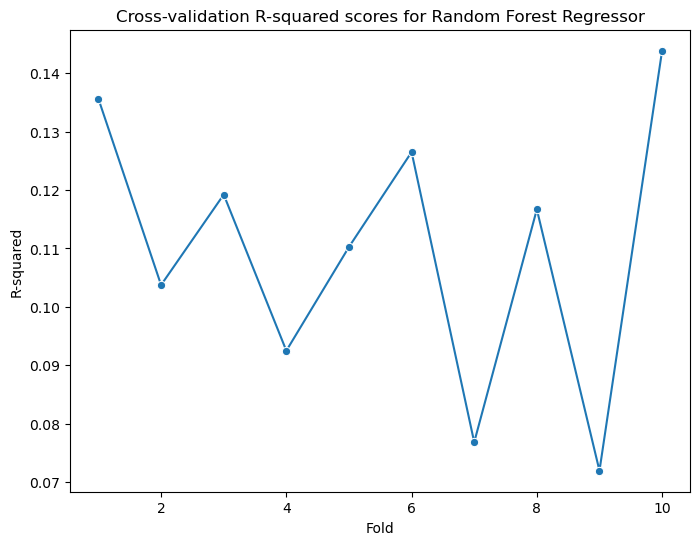

In [ ]:
get_r2_cross_val(model = model_rf, model_name = 'Random Forest Regressor')

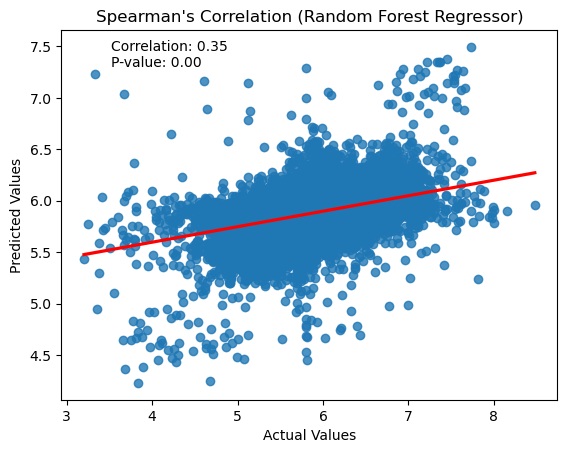

In [ ]:
get_spearman_correlation(model_predictions = predictions_rf, model_name = 'Random Forest Regressor')

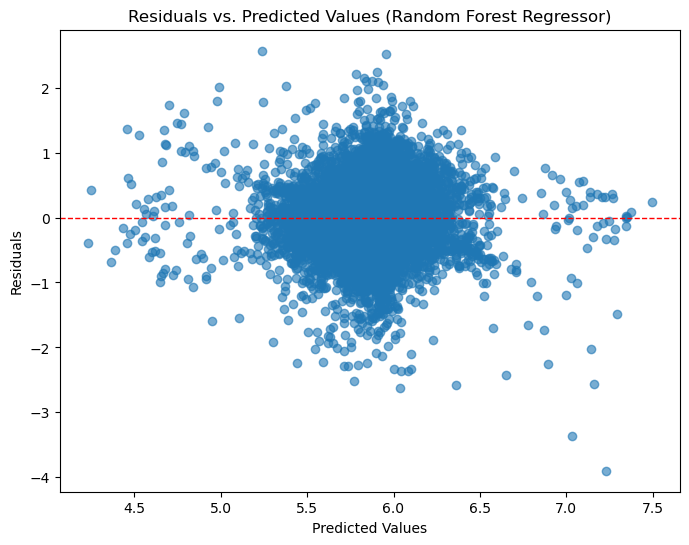

In [ ]:
get_residuals_vs_pred_plot(model_predictions = predictions_rf, model_name = 'Random Forest Regressor')

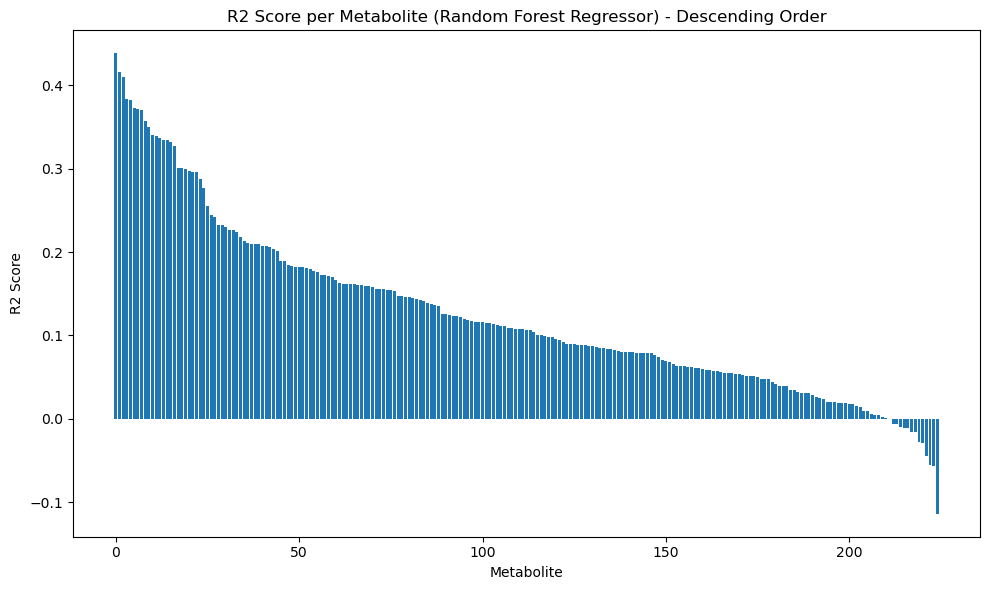

In [ ]:
plot_r2_per_metabolite(model_rf, "Random Forest Regressor", X_test, y_test)

In [ ]:
r2_rf = get_r2_per_metabolite(model_rf, "Random Forest Regressor", X_test, y_test)
r2_rf

,Metabolite,R2 Score
115,1-methylnicotinamide,0.494592
51,phosphocreatine,0.389168
34,oxalate,0.388858
188,C20:5 CE,0.335247
164,C38:4 PC,0.332549
...,...,...
57,malondialdehyde,-0.030694
96,niacinamide,-0.031128
154,C34:3 PC,-0.066768
66,glutamine,-0.090049


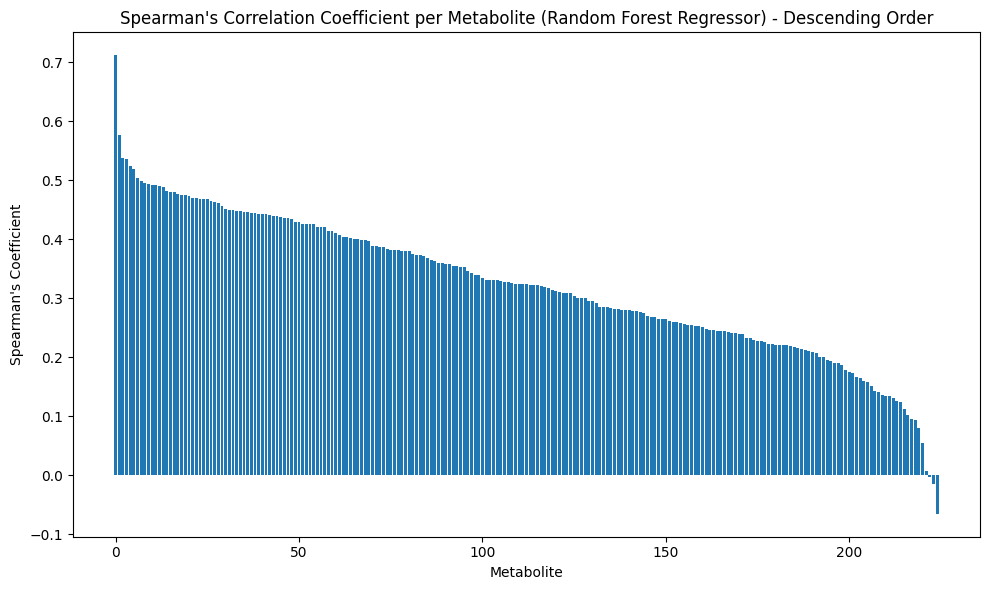

In [ ]:
plot_spearman_per_metabolite(model_rf, "Random Forest Regressor", X_test, y_test)

In [ ]:
spearman_rf = get_spearman_per_metabolite(model_rf, "Random Forest Regressor", X_test, y_test)
spearman_rf

,Metabolite,Spearman Coefficient
115,1-methylnicotinamide,0.712246
34,oxalate,0.577714
94,N-carbamoyl-beta-alanine,0.538086
188,C20:5 CE,0.537148
51,phosphocreatine,0.523807
...,...,...
126,heptanoylcarnitine,0.054401
113,pipecolic acid,0.008245
16,erythrose-4-phosphate,-0.003089
66,glutamine,-0.015225


In [ ]:
r2_rf.to_csv(f'{results_path}/r2_rf.csv', index = False)
spearman_rf.to_csv(f'{results_path}/spearman_rf.csv', index = False)

#XGBoost Regressor

In [ ]:
from xgboost import XGBRegressor

pipeline_xgb = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('pca', PCA(0.95)),
    ('model', MultiOutputRegressor(XGBRegressor(n_estimators = 100, max_depth = 5, subsample=1.0, random_state=0, n_jobs = -1), n_jobs = -1))
])

model_xgb = pipeline_xgb.fit(X_train, y_train)

In [ ]:
# pipeline_xgb = Pipeline([
#     ('imputer', SimpleImputer(strategy='mean')),
#     ('scaler', StandardScaler()),
#     ('pca', PCA(0.95)),
#     ('model', MultiOutputRegressor(XGBRegressor(random_state=0, tree_method = "hist", device = "cuda", predictor='auto', n_jobs = -1)))
# ])

In [ ]:
# xgb_param_grid = {
#     'model__estimator__n_estimators': [100, 200, 300],
#     'model__estimator__max_depth': [5, 10, 20],
#     'model__estimator__subsample': [0.5, 1.0]
# }



# xgb_grid_search = GridSearchCV(
#                                estimator=pipeline_xgb,
#                                param_grid=xgb_param_grid,
#                                scoring='neg_mean_squared_error',
#                               #  cv=5,
#                                verbose=3,
#                                n_jobs=-1
#                                )

In [ ]:
# xgb_grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


C:\Users\tkaralis\AppData\Local\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [08:51:17] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "predictor" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\tkaralis\AppData\Local\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [08:51:18] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "predictor" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\tkaralis\AppData\Local\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [08:51:19] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "predictor" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\tkarali

GridSearchCV(estimator=Pipeline(steps=[('imputer', SimpleImputer()),
                                       ('scaler', StandardScaler()),
                                       ('pca', PCA(n_components=0.95)),
                                       ('model',
                                        MultiOutputRegressor(estimator=XGBRegressor(base_score=None,
                                                                                    booster=None,
                                                                                    callbacks=None,
                                                                                    colsample_bylevel=None,
                                                                                    colsample_bynode=None,
                                                                                    colsample_bytree=None,
                                                                                    device='cuda',
                                                                                    early_stopping_rounds=None,
                                                                                    enable_categorical=...
                                                                                    min_child_weight=None,
                                                                                    missing=nan,
                                                                                    monotone_constraints=None,
                                                                                    multi_strategy=None,
                                                                                    n_estimators=None,
                                                                                    n_jobs=-1,
                                                                                    num_parallel_tree=None,
                                                                                    predictor='auto', ...)))]),
             n_jobs=-1,
             param_grid={'model__estimator__max_depth': [5, 10, 20],
                         'model__estimator__n_estimators': [100, 200, 300],
                         'model__estimator__subsample': [0.5, 1.0]},
             scoring='neg_mean_squared_error', verbose=3)

In [ ]:
# print("Best Parameters:", xgb_grid_search.best_params_)
# print("Best Score:", xgb_grid_search.best_score_)

Best Parameters: {'model__estimator__max_depth': 5, 'model__estimator__n_estimators': 100, 'model__estimator__subsample': 1.0}
Best Score: -0.1347563978447172


In [ ]:
# model_xgb = xgb_grid_search.best_estimator_

In [ ]:
save_model(model = model_xgb, model_name = 'XGBoost Regressor')

In [ ]:
predictions_xgb = model_xgb.predict(X_test)

R-squared: 0.00393393961712718
Mean Squared Error (MSE): 0.13050510999238768
Root Mean Squared Error (RMSE): 0.3612549099906985


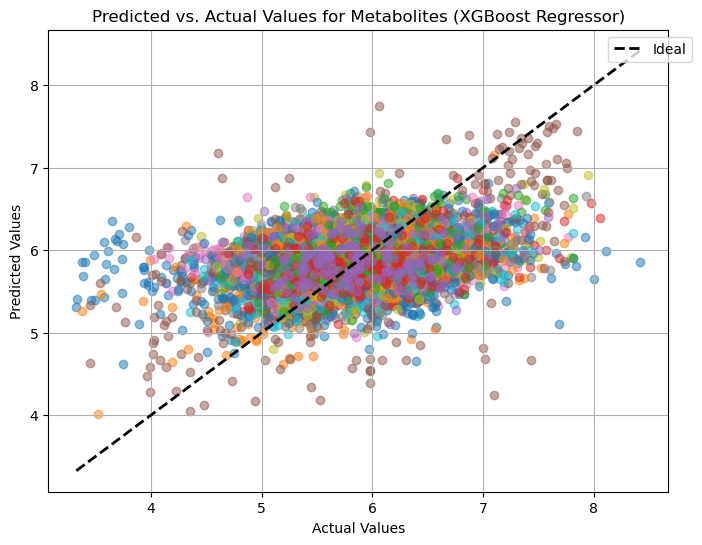

In [ ]:
get_r2_mse_rmse_plot_pred(data_y_test = y_test, model_predictions = predictions_xgb, model_type = 'XGBoost Regressor')

Cross-validation scores: [-0.13582186 -0.13783224 -0.13169408 -0.13053908 -0.13546435 -0.12853248
 -0.13176573 -0.13307523 -0.13627371 -0.13377634]
Average score: -0.1334775107238388


C:\Users\tkaralis\AppData\Local\Temp\ipykernel_58088\2128722762.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


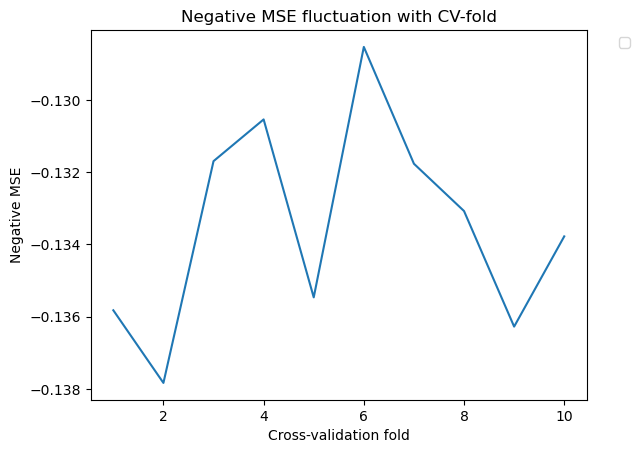

In [ ]:
plot_cv_scores(model_pipeline = model_xgb, model_type = 'Multi-output XGBoost Regressor', cv_fold = 10)

Cross-validation R-squared scores: [-0.01315725  0.05949172  0.03512051  0.00878134 -0.00022431 -0.03405728
  0.00805227  0.01174513  0.03917854  0.04327349]
Average R-squared score: 0.01582041506044334


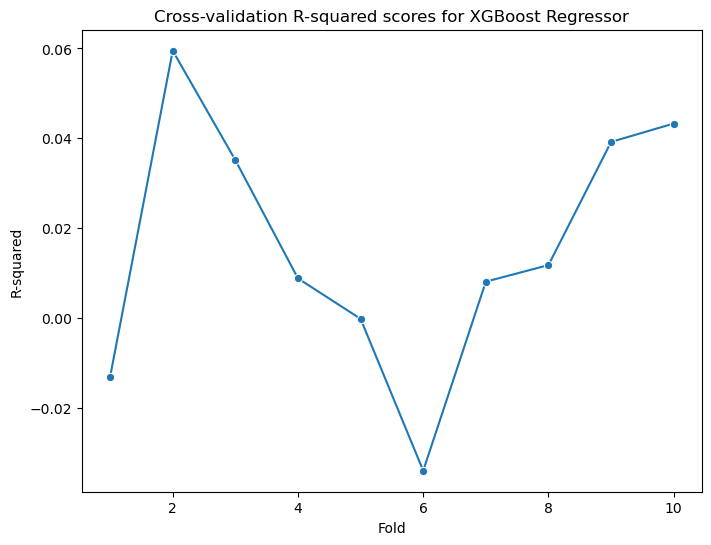

In [ ]:
get_r2_cross_val(model = model_xgb, model_name = 'XGBoost Regressor')

In [ ]:
get_metrics(y_predicted = predictions_xgb)

MSE: 0.13050510999238768
MAE: 0.2618345112491129
MedAE: 0.21056901892904892
Mean absolute percentage error: 4.5154730359554565


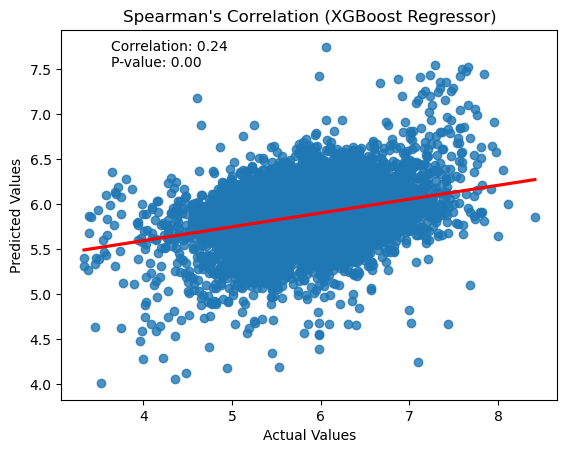

In [ ]:
get_spearman_correlation(model_predictions = predictions_xgb, model_name = 'XGBoost Regressor')

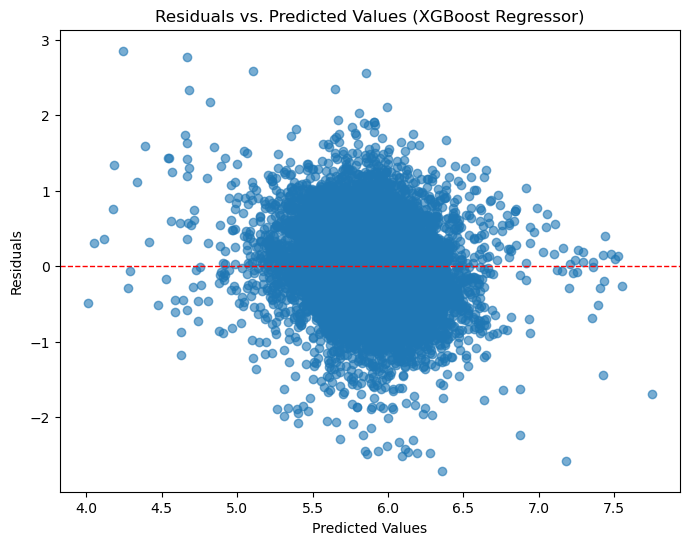

In [ ]:
get_residuals_vs_pred_plot(model_predictions = predictions_xgb, model_name = 'XGBoost Regressor')

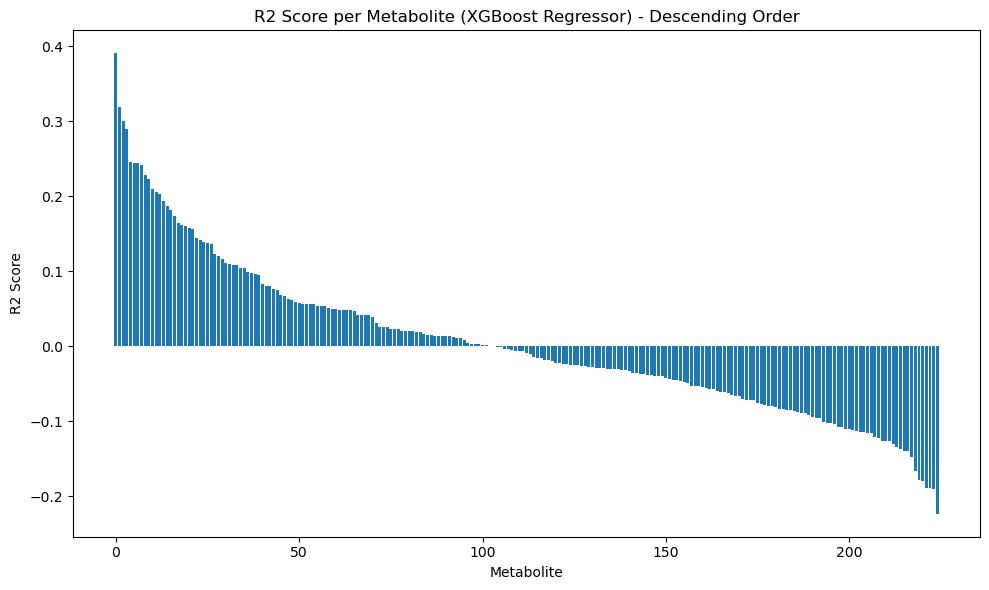

In [ ]:
plot_r2_per_metabolite(model_xgb, "XGBoost Regressor", X_test, y_test)

In [ ]:
r2_xgb = get_r2_per_metabolite(model_xgb, "XGBoost Regressor", X_test, y_test)
r2_xgb

,Metabolite,R2 Score
115,1-methylnicotinamide,0.383186
8,AMP,0.335356
47,xanthine,0.324802
42,UMP,0.320086
91,kynurenic acid,0.318454
...,...,...
82,serotonin,-0.210732
106,adenosine,-0.216812
64,glutamate,-0.256583
43,UDP-galactose/UDP-glucose,-0.316126


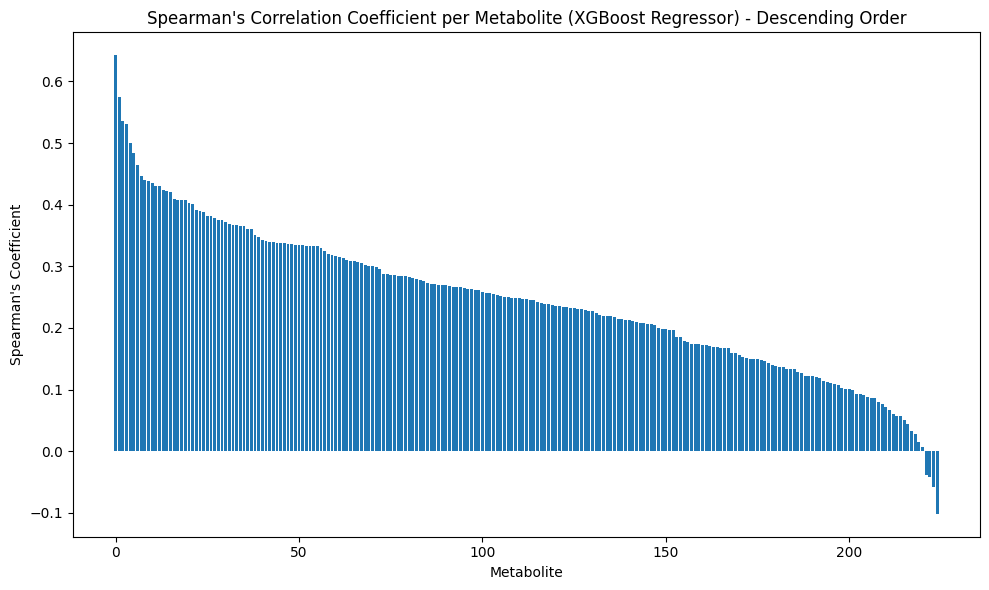

In [ ]:
plot_spearman_per_metabolite(model_xgb, "XGBoost Regressor", X_test, y_test)

In [ ]:
spearman_xgb = get_spearman_per_metabolite(model_xgb, "XGBoost Regressor", X_test, y_test)
spearman_xgb

,Metabolite,Spearman Coefficient
115,1-methylnicotinamide,0.642361
51,phosphocreatine,0.575356
191,C22:6 CE,0.534939
188,C20:5 CE,0.531438
67,histidine,0.499444
...,...,...
57,malondialdehyde,0.007706
100,acetylcholine,-0.037951
81,5-HIAA,-0.042228
113,pipecolic acid,-0.058132


In [ ]:
r2_xgb.to_csv(f'{results_path}/r2_xgb.csv', index = False)
spearman_xgb.to_csv(f'{results_path}/spearman_xgb.csv', index = False)

#LightGBM Regressor

In [ ]:
pipeline_lgbm = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('pca', PCA(0.95)),
    ('model', MultiOutputRegressor(LGBMRegressor(n_estimators = 100, max_depth= 5, num_leaves = 30, random_state=0, n_jobs = -1)))
])

best_lgbm_model = pipeline_lgbm.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009461 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 108712
[LightGBM] [Info] Number of data points in the train set: 727, number of used features: 448
[LightGBM] [Info] Start training from score 5.937933
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005913 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 108712
[LightGBM] [Info] Number of data points in the train set: 727, number of used features: 448
[LightGBM] [Info] Start training from score 5.874856
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010110 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 108712
[LightGBM] [Info] Number of data points in the train set: 727, number of used features: 448
[LightGBM] [Info] Start training from score 5.916107
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [ ]:
# pipeline_lgbm = Pipeline([
#     ('imputer', SimpleImputer(strategy='mean')),
#     ('scaler', StandardScaler()),
#     ('pca', PCA(0.95)),
#     ('model', MultiOutputRegressor(LGBMRegressor(random_state=0, n_jobs = -1), n_jobs = -1))
# ])

# lgbm_param_grid = {
#     'model__estimator__n_estimators': [100, 150, 200, 250, 300, 500],
#     'model__estimator__max_depth': [5, 10, 20, 30, 50],
#     'model__estimator__num_leaves': [30, 50, 100, 200]
# }

# grid_search_lgbm = GridSearchCV(
#     estimator=pipeline_lgbm,
#     param_grid=lgbm_param_grid,
#     scoring='neg_mean_squared_error',
#     # cv=5,
#     verbose=3,
#     n_jobs=-1
# )

In [ ]:
# grid_search_lgbm.fit(X_train, y_train)

Fitting 5 folds for each of 120 candidates, totalling 600 fits


C:\Users\tkaralis\AppData\Local\anaconda3\Lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


GridSearchCV(estimator=Pipeline(steps=[('imputer', SimpleImputer()),
                                       ('scaler', StandardScaler()),
                                       ('pca', PCA(n_components=0.95)),
                                       ('model',
                                        MultiOutputRegressor(estimator=LGBMRegressor(n_jobs=-1,
                                                                                     random_state=0),
                                                             n_jobs=-1))]),
             n_jobs=-1,
             param_grid={'model__estimator__max_depth': [5, 10, 20, 30, 50],
                         'model__estimator__n_estimators': [100, 150, 200, 250,
                                                            300, 500],
                         'model__estimator__num_leaves': [31, 50, 100, 200]},
             scoring='neg_mean_squared_error', verbose=3)

In [ ]:
# print("Best Parameters:", grid_search_lgbm.best_params_)
# print("Best Score:", grid_search_lgbm.best_score_)

Best Parameters: {'model__estimator__max_depth': 5, 'model__estimator__n_estimators': 100, 'model__estimator__num_leaves': 31}
Best Score: -0.12688551371625872


In [ ]:
# best_lgbm_model = grid_search_lgbm.best_estimator_

In [ ]:
save_model(model = best_lgbm_model, model_name = 'LightGBM Regressor')

In [ ]:
predictions_lgbm = best_lgbm_model.predict(X_test)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

R-squared: 0.09528394734705671
Mean Squared Error (MSE): 0.12093971092421492
Root Mean Squared Error (RMSE): 0.3477638723677532


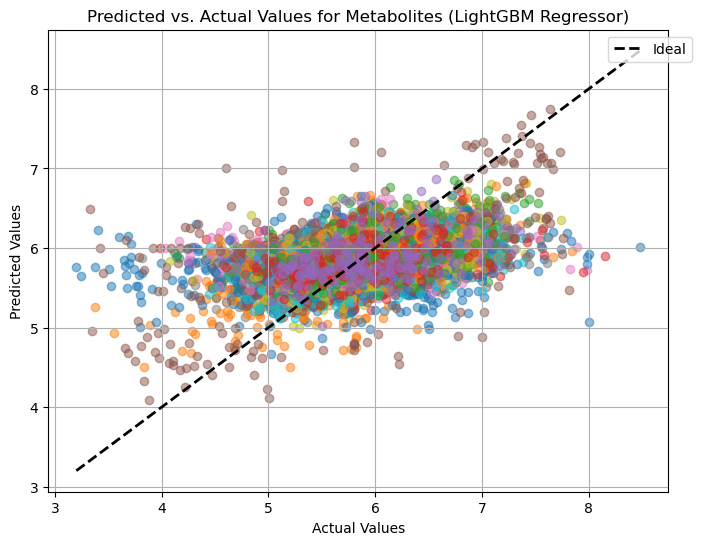

In [ ]:
get_r2_mse_rmse_plot_pred(data_y_test = y_test, model_predictions = predictions_lgbm, model_type = 'LightGBM Regressor')

Cross-validation scores: [-0.11669948 -0.12428712 -0.12453425 -0.12943711 -0.11883401 -0.12431082
 -0.12300121 -0.12757529 -0.12417585 -0.12665819]
Average score: -0.12395133372814364


C:\Users\tkaralis\AppData\Local\Temp\ipykernel_7976\2128722762.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


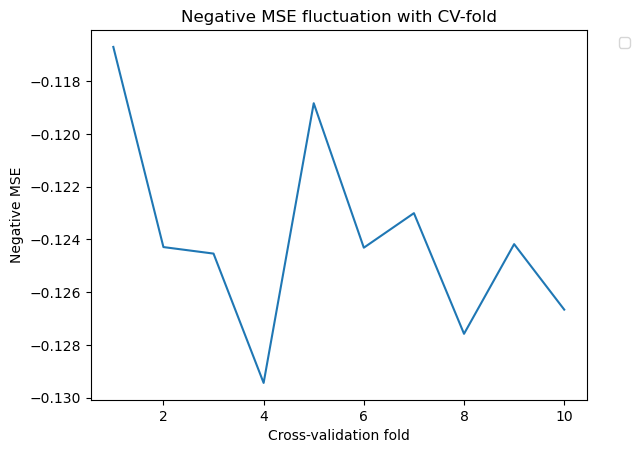

In [ ]:
plot_cv_scores(model_pipeline = best_lgbm_model, model_type = 'Multi-output LightGBM Regressor', cv_fold = 10)

Cross-validation R-squared scores: [0.10658262 0.07264404 0.08992703 0.06881344 0.09031035 0.08679938
 0.03852607 0.07964165 0.04502402 0.12245781]
Average R-squared score: 0.08007264044600207


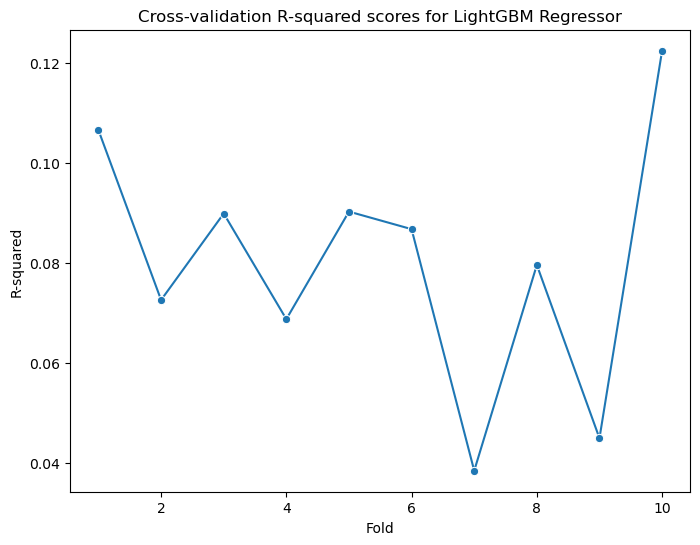

In [ ]:
get_r2_cross_val(model = best_lgbm_model, model_name = 'LightGBM Regressor')

In [ ]:
get_metrics(y_predicted = predictions_lgbm)

MSE: 0.12093971092421492
MAE: 0.25185371758673575
MedAE: 0.20275313922844146
Mean absolute percentage error: 4.344098797267072


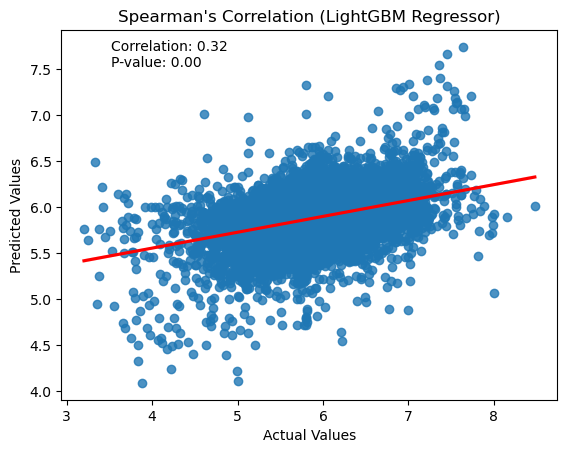

In [ ]:
get_spearman_correlation(model_predictions = predictions_lgbm, model_name = 'LightGBM Regressor')

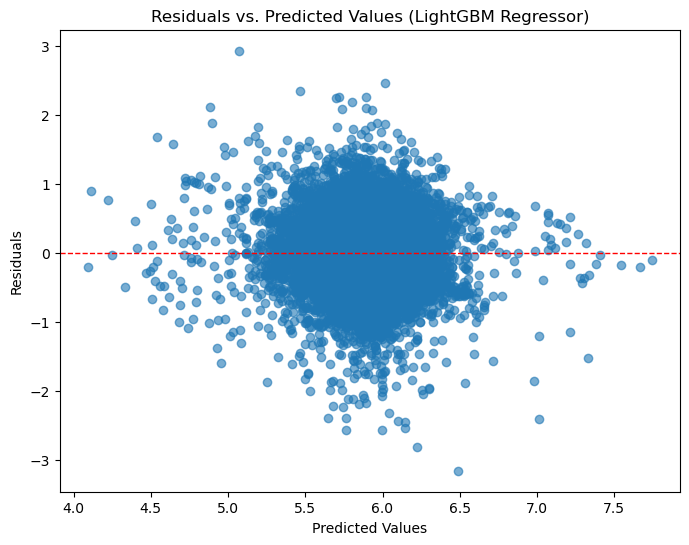

In [ ]:
get_residuals_vs_pred_plot(model_predictions = predictions_lgbm, model_name = 'LightGBM Regressor')

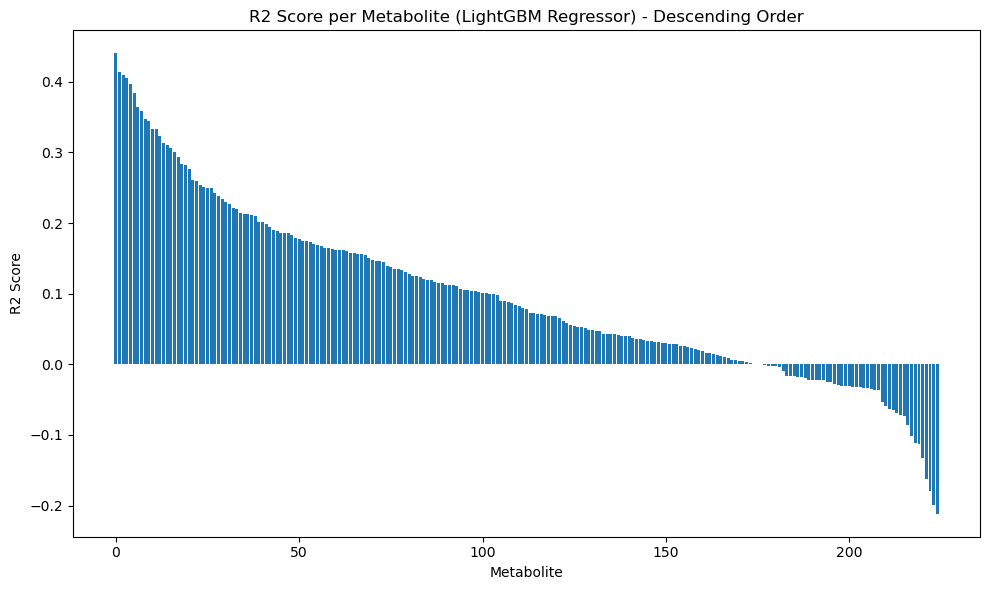

In [ ]:
plot_r2_per_metabolite(best_lgbm_model, "LightGBM Regressor", X_test, y_test)

In [ ]:
r2_lgbm = get_r2_per_metabolite(best_lgbm_model, "LightGBM Regressor", X_test, y_test)
r2_lgbm

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

,Metabolite,R2 Score
115,1-methylnicotinamide,0.543845
51,phosphocreatine,0.386113
34,oxalate,0.356381
188,C20:5 CE,0.327094
186,C18:1 CE,0.322598
...,...,...
86,homocysteine,-0.101186
57,malondialdehyde,-0.110883
96,niacinamide,-0.143462
113,pipecolic acid,-0.163694


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

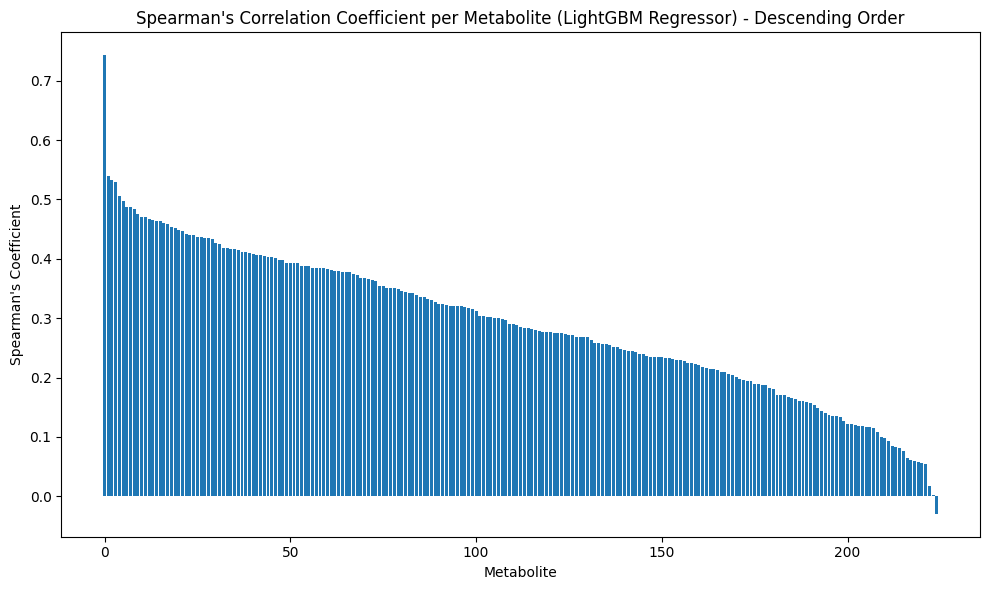

In [ ]:
plot_spearman_per_metabolite(best_lgbm_model, "LightGBM Regressor", X_test, y_test)

In [ ]:
spearman_lgbm = get_spearman_per_metabolite(best_lgbm_model, "LightGBM Regressor", X_test, y_test)
spearman_lgbm

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

,Metabolite,Spearman Coefficient
115,1-methylnicotinamide,0.742949
34,oxalate,0.539421
186,C18:1 CE,0.532453
188,C20:5 CE,0.529330
51,phosphocreatine,0.506501
...,...,...
57,malondialdehyde,0.056551
126,heptanoylcarnitine,0.054178
82,serotonin,0.017276
16,erythrose-4-phosphate,0.002631


In [ ]:
r2_lgbm.to_csv(f'{results_path}/r2_lgbm.csv', index = False)
spearman_lgbm.to_csv(f'{results_path}/spearman_lgbm.csv', index = False)

#MLP Regressor

In [ ]:
from sklearn.neural_network import MLPRegressor

In [ ]:
pipeline_mlp = Pipeline([
    ('imputer', SimpleImputer(strategy = 'mean')),
    ('scaler', StandardScaler()),
    ('pca', PCA(0.95)),
    ('model', MLPRegressor(activation = 'tanh',
                           alpha = 10,
                           batch_size = 64,
                           early_stopping = True,
                           hidden_layer_sizes = (50, 50),
                           solver = 'sgd',
                           random_state = 0,
                           learning_rate = 'adaptive'))
])

best_mlp_model = pipeline_mlp.fit(X_train, y_train)

In [ ]:
# pipeline_mlp = Pipeline([
#     ('imputer', SimpleImputer(strategy = 'mean')),
#     ('scaler', StandardScaler()),
#     ('pca', PCA(0.95)),
#     ('model', MLPRegressor(random_state = 0, learning_rate = 'adaptive'))
# ])


# param_grid_mlp = {
#     'model__hidden_layer_sizes': [(100,), (50, 50), (100, 50, 25)],
#     'model__activation': ['relu', 'tanh'],
#     'model__solver': ['adam', 'sgd'],
#     'model__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100],
#     'model__batch_size': [32, 64, 128],
#     'model__early_stopping': [True, False]
# }


# grid_search_mlp = GridSearchCV(
#     estimator = pipeline_mlp,
#     param_grid = param_grid_mlp,
#     scoring = 'neg_mean_squared_error',
#     verbose = 3,
#     n_jobs = -1
# )

# grid_search_mlp.fit(X_train, y_train)

Fitting 5 folds for each of 504 candidates, totalling 2520 fits


C:\Users\tkaralis\AppData\Local\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
397 fits failed out of a total of 2520.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
182 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\tkaralis\AppData\Local\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\tkaralis\AppData\Local\anaconda3\Lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\tkaralis\AppData\Local\anaconda3\Lib\site-packa

GridSearchCV(estimator=Pipeline(steps=[('imputer', SimpleImputer()),
                                       ('scaler', StandardScaler()),
                                       ('pca', PCA(n_components=0.95)),
                                       ('model',
                                        MLPRegressor(learning_rate='adaptive',
                                                     random_state=0))]),
             n_jobs=-1,
             param_grid={'model__activation': ['relu', 'tanh'],
                         'model__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100],
                         'model__batch_size': [32, 64, 128],
                         'model__early_stopping': [True, False],
                         'model__hidden_layer_sizes': [(100,), (50, 50),
                                                       (100, 50, 25)],
                         'model__solver': ['adam', 'sgd']},
             scoring='neg_mean_squared_error', verbose=3)

In [ ]:
# print("Best Parameters:", grid_search_mlp.best_params_)
# print("Best Score:", grid_search_mlp.best_score_)

Best Parameters: {'model__activation': 'tanh', 'model__alpha': 10, 'model__batch_size': 64, 'model__early_stopping': True, 'model__hidden_layer_sizes': (50, 50), 'model__solver': 'sgd'}
Best Score: -0.12658385210774686


In [ ]:
# best_mlp_model = grid_search_mlp.best_estimator_

In [ ]:
save_model(model = best_mlp_model, model_name = 'MLP Regressor')

In [ ]:
predictions_mlp = best_mlp_model.predict(X_test)

R-squared: 0.1141101308841938
Mean Squared Error (MSE): 0.11860137836349356
Root Mean Squared Error (RMSE): 0.34438550835291193


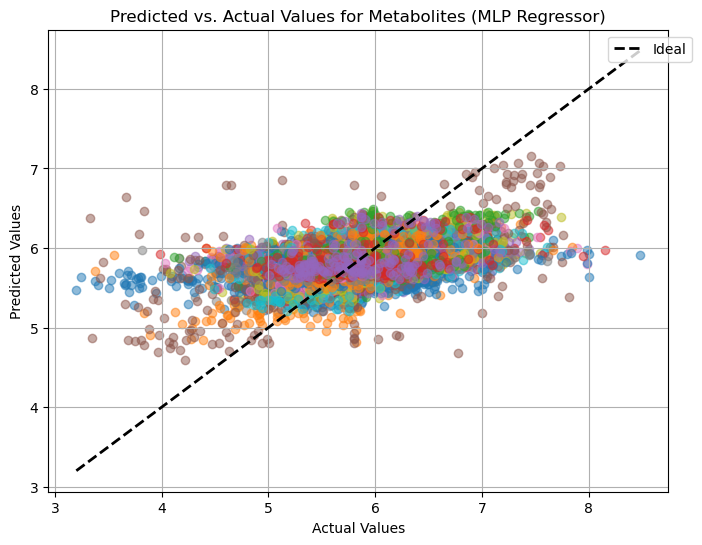

In [ ]:
get_r2_mse_rmse_plot_pred(data_y_test = y_test, model_predictions = predictions_mlp, model_type = 'MLP Regressor')

Cross-validation scores: [-0.116428   -0.1247214  -0.12426777 -0.12968451 -0.11756086 -0.11882509
 -0.12513134 -0.12432252 -0.12497776 -0.12347205]
Average score: -0.1229391308067694


C:\Users\tkaralis\AppData\Local\Temp\ipykernel_7976\2128722762.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


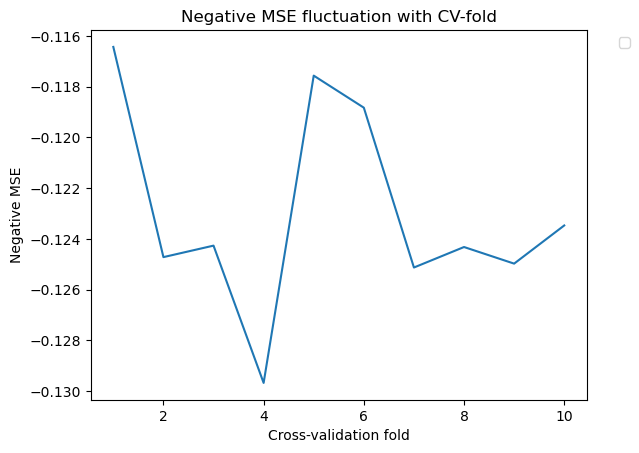

In [ ]:
plot_cv_scores(model_pipeline = best_mlp_model, model_type = 'MLP Regressor', cv_fold = 10)

Cross-validation R-squared scores: [0.10994011 0.08231949 0.08597968 0.06652924 0.07413389 0.08560027
 0.07339084 0.08437157 0.03849701 0.095445  ]
Average R-squared score: 0.07962071073411478


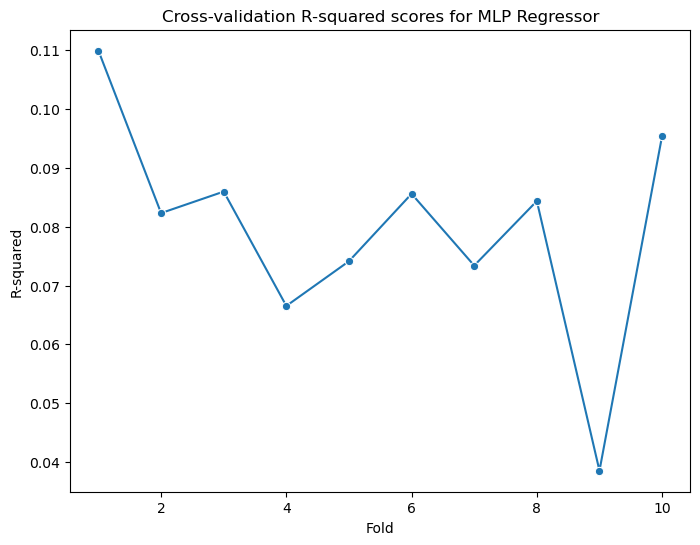

In [ ]:
get_r2_cross_val(model = best_mlp_model, model_name = 'MLP Regressor')

In [ ]:
get_metrics(y_predicted = predictions_mlp)

MSE: 0.11860137836349356
MAE: 0.24863230371403305
MedAE: 0.20069329780304582
Mean absolute percentage error: 4.273669552939708


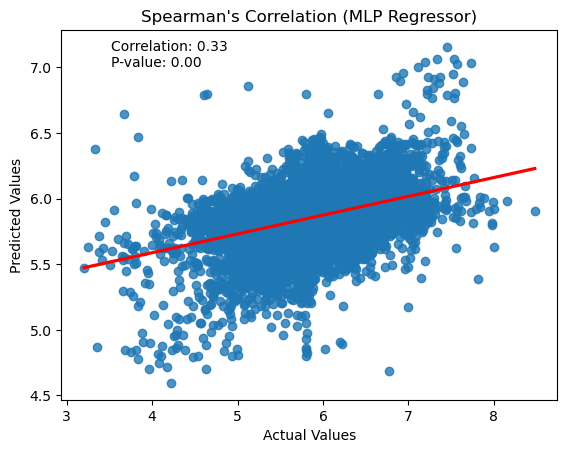

In [ ]:
get_spearman_correlation(model_predictions = predictions_mlp, model_name = 'MLP Regressor')

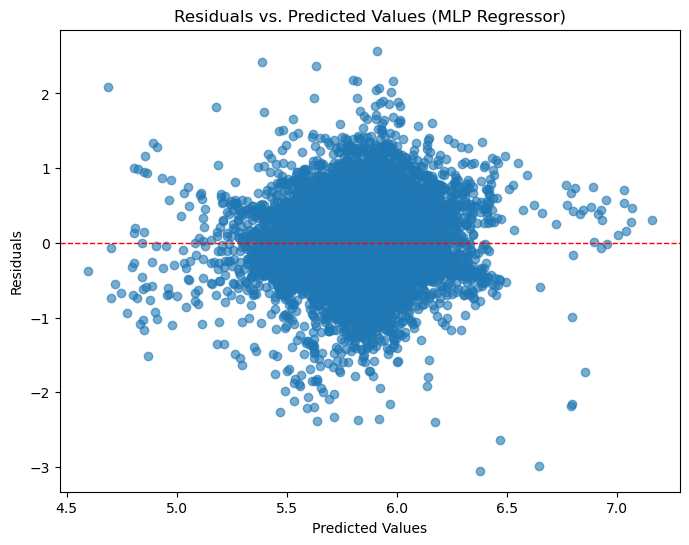

In [ ]:
get_residuals_vs_pred_plot(model_predictions = predictions_mlp, model_name = 'MLP Regressor')

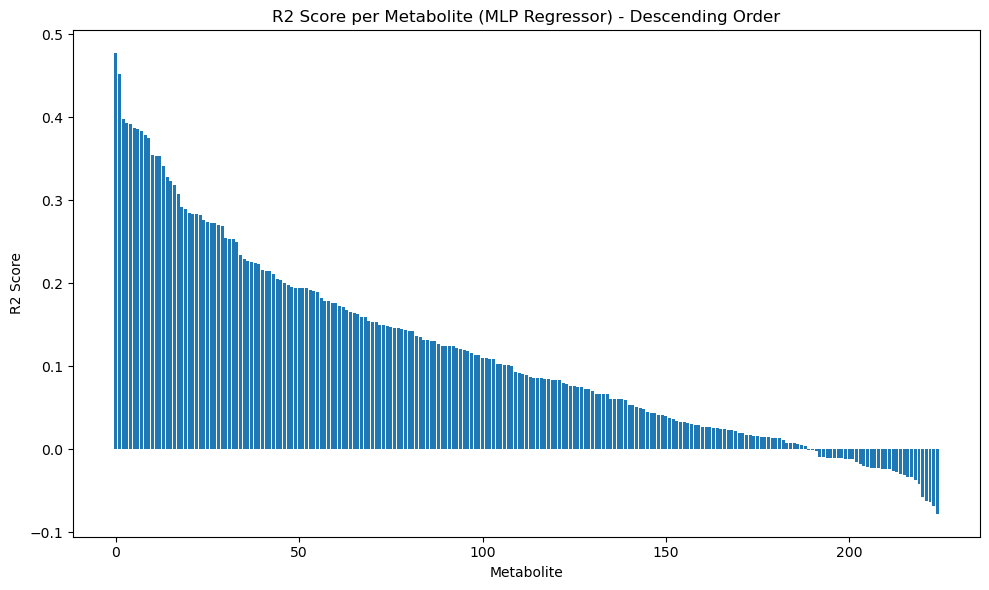

In [ ]:
plot_r2_per_metabolite(best_mlp_model, "MLP Regressor", X_test, y_test)

In [ ]:
r2_mlp = get_r2_per_metabolite(best_mlp_model, "MLP Regressor", X_test, y_test)
r2_mlp

,Metabolite,R2 Score
115,1-methylnicotinamide,0.510193
91,kynurenic acid,0.375571
188,C20:5 CE,0.338158
186,C18:1 CE,0.335985
102,creatinine,0.333582
...,...,...
169,C16:0 SM,-0.031198
165,C38:2 PC,-0.036997
16,erythrose-4-phosphate,-0.038407
138,C16:0 LPC,-0.044102


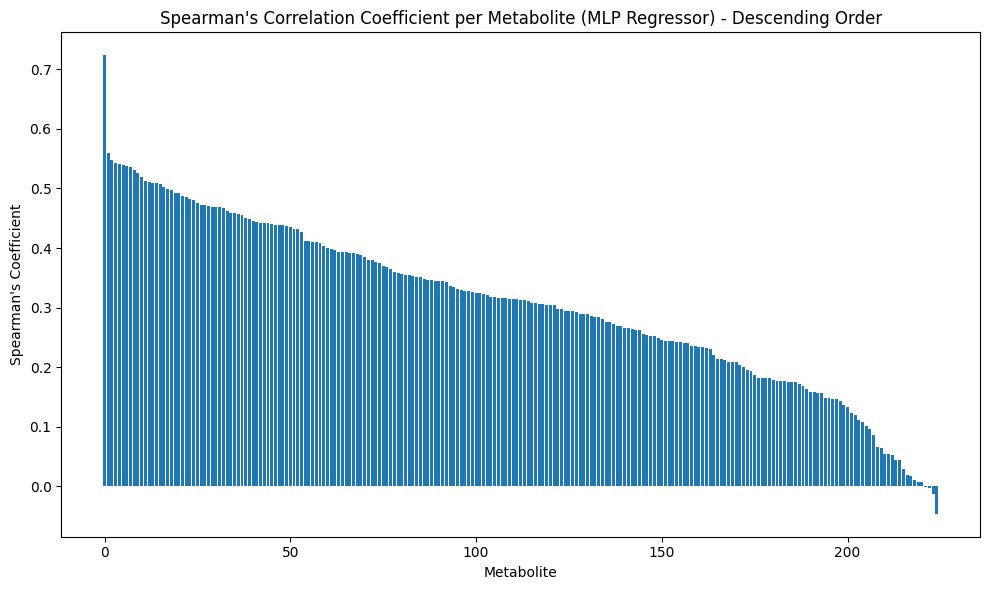

In [ ]:
plot_spearman_per_metabolite(best_mlp_model, "MLP Regressor", X_test, y_test)

In [ ]:
spearman_mlp = get_spearman_per_metabolite(best_mlp_model, "MLP Regressor", X_test, y_test)
spearman_mlp

,Metabolite,Spearman Coefficient
115,1-methylnicotinamide,0.723367
188,C20:5 CE,0.559512
34,oxalate,0.547069
67,histidine,0.543370
87,SDMA/ADMA,0.541402
...,...,...
138,C16:0 LPC,0.007158
31,malate,-0.001347
137,C16:1 LPC,-0.001945
141,C18:0 LPC,-0.012094


In [ ]:
r2_mlp.to_csv(f'{results_path}/r2_mlp.csv', index = False)
spearman_mlp.to_csv(f'{results_path}/spearman_mlp.csv', index = False)